# Plant Health Assessment

## Project Overview

This notebook implements deep learning models for:
1. **Plant Health Assessment**: Binary classification (healthy vs. diseased)

## Setup Instructions for Google Colab

1. **Enable GPU**: Runtime → Change runtime type → GPU (T4 or better)
2. **Run all cells in order** - datasets will download automatically

## Datasets
- **Plant Village**: Health assessment (54,304 images, 14 species)



# Dataset Information


For this project, datasets:

**Plant Village Dataset** - Plant disease classification
   - Download: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
   - Contains healthy and diseased plant images
   

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.transforms import v2

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import torch.nn.functional as F

import shutil
import random
import glob


torch.manual_seed(42)
np.random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


Using device: cuda


In [2]:
# ============================================
# STEP 1: Download Dataset from Kaggle
# ============================================
# This cell downloads the Plant Village dataset directly in Colab

try:
    import kagglehub
except ImportError:
    print("Installing kagglehub...")
    %pip install kagglehub
    import kagglehub

# Download the dataset
print("=" * 60)
print("DOWNLOADING PLANT VILLAGE DATASET FROM KAGGLE")
print("=" * 60)
print("This may take a few minutes...")

dataset_path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")
print(f"\n✓ Dataset downloaded to: {dataset_path}")

archive_path = Path(dataset_path)

# Find the actual dataset folder (it might be nested)
possible_locations = [
    archive_path / "plantvillage dataset" / "color",
    archive_path / "plantvillage dataset" / "PlantVillage",
    archive_path / "PlantVillage",
    archive_path,
]

for loc in possible_locations:
    if loc.exists():
        subdirs = [d for d in loc.iterdir() if d.is_dir()]
        if subdirs and any('___' in d.name for d in subdirs):
            print(f"✓ Found dataset at: {loc}")
            ARCHIVE_PATH = str(loc)
            break
else:
    ARCHIVE_PATH = str(archive_path)
    print(f"✓ Using archive path: {ARCHIVE_PATH}")

print("\nDataset ready! Proceed to next cell to organize it.")


DOWNLOADING PLANT VILLAGE DATASET FROM KAGGLE
This may take a few minutes...
Using Colab cache for faster access to the 'plantvillage-dataset' dataset.

✓ Dataset downloaded to: /kaggle/input/plantvillage-dataset
✓ Found dataset at: /kaggle/input/plantvillage-dataset/plantvillage dataset/color

Dataset ready! Proceed to next cell to organize it.


In [3]:

# ============================================
# STEP 2: Organize Dataset
# ============================================

def organize_plantvillage_dataset(archive_path, output_path='data',
                                  train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    """
    Organize Plant Village dataset from archive folder
    """
    archive_dir = Path(archive_path)
    output_dir = Path(output_path)

    plantvillage_dir = None

    possible_paths = [
        archive_dir / 'plantvillage dataset' / 'color',
        archive_dir / 'plantvillage dataset' / 'PlantVillage',
        archive_dir / 'PlantVillage',
        archive_dir / 'plantvillage',
        archive_dir,
    ]

    for path in possible_paths:
        if path.exists() and path.is_dir():
            subdirs = [d for d in path.iterdir() if d.is_dir()]
            if subdirs and any('___' in d.name for d in subdirs):
                plantvillage_dir = path
                break

    if plantvillage_dir is None:
        print(f"[ERROR] Could not find Plant Village dataset in {archive_path}")
        return False

    print(f"[OK] Found Plant Village dataset at: {plantvillage_dir}")

    # Create output directories
    for split in ['train', 'val', 'test']:
        (output_dir / split).mkdir(parents=True, exist_ok=True)

    # Process each plant folder
    plant_folders = [d for d in plantvillage_dir.iterdir() if d.is_dir()]

    if len(plant_folders) == 0:
        print(f" No plant folders found")
        return False

    print(f"\nFound {len(plant_folders)} plant categories")
    print("Organizing dataset...")

    # Group by plant species
    plant_species = {}

    for folder in plant_folders:
        if '___' in folder.name:
            parts = folder.name.split('___')
            if len(parts) == 2:
                plant_name = parts[0]
                condition = parts[1]

                if plant_name not in plant_species:
                    plant_species[plant_name] = {}

                # Categorize as healthy or diseased
                if condition.lower() == 'healthy':
                    health_status = 'healthy'
                else:
                    health_status = 'diseased'

                if health_status not in plant_species[plant_name]:
                    plant_species[plant_name][health_status] = []

                # Get all images
                images = list(folder.glob('*.jpg')) + list(folder.glob('*.png')) + \
                         list(folder.glob('*.JPG')) + list(folder.glob('*.PNG'))

                plant_species[plant_name][health_status].extend(images)

    print(f"\nFound {len(plant_species)} plant species")

    # Organize and split
    total_images = 0
    processed_species = 0

    for plant_name, health_data in plant_species.items():
        total_imgs = sum(len(imgs) for imgs in health_data.values())
        if total_imgs == 0:
            continue

        has_healthy = 'healthy' in health_data and len(health_data['healthy']) > 0
        has_diseased = 'diseased' in health_data and len(health_data['diseased']) > 0

        if not has_healthy and not has_diseased:
            continue

        processed_species += 1

        # Process each health status
        for health_status in ['healthy', 'diseased']:
            if health_status not in health_data or len(health_data[health_status]) == 0:
                continue

            images = health_data[health_status]

            if len(images) < 3:
                continue

            # Split images
            random.seed(42)
            random.shuffle(images)

            train_end = int(len(images) * train_ratio)
            val_end = train_end + int(len(images) * val_ratio)

            train_imgs = images[:train_end]
            val_imgs = images[train_end:val_end]
            test_imgs = images[val_end:]

            # Copy to respective directories
            for split, imgs in [('train', train_imgs), ('val', val_imgs), ('test', test_imgs)]:
                for img in imgs:
                    # For health assessment: data/train/plant_name/health_status/image.jpg
                    dest_health = output_dir / split / plant_name / health_status / img.name
                    dest_health.parent.mkdir(parents=True, exist_ok=True)
                    shutil.copy2(img, dest_health)

            total_images += len(images)
            print(f"  [OK] {plant_name}/{health_status}: {len(train_imgs)} train, {len(val_imgs)} val, {len(test_imgs)} test")

    print(f"\n{'='*60}")
    print(f"[SUCCESS] Dataset organized successfully!")
    print(f"  - Processed {processed_species} plant species")
    print(f"  - Total images: {total_images}")
    print(f"  - Output directory: {output_dir}")
    print(f"{'='*60}")

    return True

print("=" * 60)
print("ORGANIZING PLANT VILLAGE DATASET")
print("=" * 60)

# Use ARCHIVE_PATH from previous cell, or set it manually if needed
if 'ARCHIVE_PATH' not in globals():
    possible_paths = glob.glob("**/plantvillage*", recursive=True)
    if possible_paths:
        ARCHIVE_PATH = possible_paths[0]
    else:
        ARCHIVE_PATH = dataset_path

success = organize_plantvillage_dataset(
    archive_path=ARCHIVE_PATH,
    output_path='data',
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15
)

if success:
    print("\n✓ Dataset ready for training!")
else:
    print("\n Error organizing dataset. Please check the archive path.")


ORGANIZING PLANT VILLAGE DATASET
[OK] Found Plant Village dataset at: /kaggle/input/plantvillage-dataset/plantvillage dataset/color

Found 38 plant categories
Organizing dataset...

Found 14 plant species
  [OK] Tomato/healthy: 1113 train, 238 val, 240 test
  [OK] Tomato/diseased: 11597 train, 2485 val, 2486 test
  [OK] Grape/healthy: 296 train, 63 val, 64 test
  [OK] Grape/diseased: 2547 train, 545 val, 547 test
  [OK] Orange/diseased: 3854 train, 826 val, 827 test
  [OK] Soybean/healthy: 3563 train, 763 val, 764 test
  [OK] Squash/diseased: 1284 train, 275 val, 276 test
  [OK] Potato/healthy: 106 train, 22 val, 24 test
  [OK] Potato/diseased: 1400 train, 300 val, 300 test
  [OK] Corn_(maize)/healthy: 813 train, 174 val, 175 test
  [OK] Corn_(maize)/diseased: 1882 train, 403 val, 405 test
  [OK] Strawberry/healthy: 319 train, 68 val, 69 test
  [OK] Strawberry/diseased: 776 train, 166 val, 167 test
  [OK] Peach/healthy: 251 train, 54 val, 55 test
  [OK] Peach/diseased: 1607 train, 344 

In [5]:
# ============================================
# CONFIGURATION: Auto-detect Colab
# ============================================
# Auto-detect if running on Google Colab
try:
    import google.colab
    RUNNING_ON_COLAB = True
except ImportError:
    RUNNING_ON_COLAB = False

SAVE_TO_DRIVE = False  # Set to True to save models to Google Drive (persists after session)

# Data loading workers (0 for Windows, 2+ for Colab/Linux)
NUM_WORKERS = 0 if not RUNNING_ON_COLAB else 2

if RUNNING_ON_COLAB and SAVE_TO_DRIVE:
    MODEL_DIR = '/content/drive/MyDrive/models'  # Save to Drive
    import os
    os.makedirs(MODEL_DIR, exist_ok=True)
else:
    MODEL_DIR = 'models'  # Save locally
    import os
    os.makedirs(MODEL_DIR, exist_ok=True)

print(f"Configuration:")
print(f"  Running on Colab: {RUNNING_ON_COLAB}")
print(f"  Save to Drive: {SAVE_TO_DRIVE}")
print(f"  Num workers: {NUM_WORKERS}")
print(f"  Model directory: {MODEL_DIR}")


Configuration:
  Running on Colab: True
  Save to Drive: False
  Num workers: 2
  Model directory: models


## Dataset Class Definition

This section defines the custom PyTorch Dataset class that loads and preprocesses plant images for training. It handles both plant identification and health assessment modes.


## Data Augmentation and Transformations

This section defines data augmentation strategies (random flips, rotations, color jittering) for training data to improve model generalization, and standard preprocessing for validation/test data.


## Training Class Implementation

This section implements the Trainer class that handles the training loop, validation, learning rate scheduling, early stopping, and tracks training history (losses and accuracies).


In [6]:
class PlantDataset(Dataset):
    """
    Custom dataset class for plant
    """
    def __init__(self, data_dir, transform=None, mode='health'):
        """
        Args:
            data_dir: Root directory containing plant images
            transform: Optional transform to be applied on a sample
            mode: 'identification' for plant species classification,
                  'health' for health assessment
        """
        self.data_dir = Path(data_dir)
        self.transform = transform
        self.mode = mode
        self.samples = []
        self.classes = []

        # Collect all image files and their labels
        if self.mode == 'identification':
            # For identification: structure is data_dir/plant_species/image.jpg
            for plant_dir in sorted(self.data_dir.iterdir()):
                if plant_dir.is_dir():
                    plant_name = plant_dir.name
                    if plant_name not in self.classes:
                        self.classes.append(plant_name)

                    for img_path in plant_dir.glob('*.jpg'):
                        self.samples.append((img_path, self.classes.index(plant_name)))
                    for img_path in plant_dir.glob('*.png'):
                        self.samples.append((img_path, self.classes.index(plant_name)))
        else:
            # For health assessment: structure is data_dir/plant_species/health_status/image.jpg
            for plant_dir in self.data_dir.iterdir():
                if plant_dir.is_dir():
                    for health_dir in plant_dir.iterdir():
                        if health_dir.is_dir():
                            health_status = health_dir.name  # 'healthy' or 'diseased'
                            label = 0 if health_status == 'healthy' else 1

                            for img_path in health_dir.glob('*.jpg'):
                                self.samples.append((img_path, label))
                            for img_path in health_dir.glob('*.png'):
                                self.samples.append((img_path, label))

            self.classes = ['healthy', 'diseased']

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        # Load image
        from PIL import Image
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return a black image as fallback
            image = Image.new('RGB', (224, 224), color='black')

        if self.transform:
            image = self.transform(image)

        return image, label

    def get_class_names(self):
        return self.classes


In [7]:
# Data augmentation and preprocessing transforms
def get_transforms(mode='train', image_size=224):
    """
    Get data transformation pipeline
    """
    if mode == 'train':
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])
    else:  # validation/test
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])


In [8]:
class Trainer:
    """
    Training class with logging and evaluation
    """
    def __init__(self, model, train_loader, val_loader, device, num_classes):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.num_classes = num_classes

        # Loss and optimizer
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=3)

        # Training history
        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []
        self.best_val_acc = 0.0

    def train_epoch(self):
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in self.train_loader:
            images, labels = images.to(self.device), labels.to(self.device)

            # Forward pass
            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, labels)

            # Backward pass
            loss.backward()
            self.optimizer.step()

            # Statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(self.train_loader)
        epoch_acc = 100 * correct / total
        return epoch_loss, epoch_acc

    def validate(self):
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in self.val_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)

                running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        epoch_loss = running_loss / len(self.val_loader)
        epoch_acc = 100 * correct / total
        return epoch_loss, epoch_acc, all_preds, all_labels

    def train(self, num_epochs=50, early_stopping_patience=10):
        """
        Main training loop
        """
        patience_counter = 0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch+1}/{num_epochs}')

            # Train
            train_loss, train_acc = self.train_epoch()
            self.train_losses.append(train_loss)
            self.train_accuracies.append(train_acc)

            # Validate
            val_loss, val_acc, preds, labels = self.validate()
            self.val_losses.append(val_loss)
            self.val_accuracies.append(val_acc)

            # Learning rate scheduling
            self.scheduler.step(val_loss)

            # Print progress
            print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
            print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
            print('-' * 50)

            # Save best model
            if val_acc > self.best_val_acc:
                self.best_val_acc = val_acc
                torch.save(self.model.state_dict(), 'best_model.pth')
                patience_counter = 0
            else:
                patience_counter += 1

            # Early stopping
            if patience_counter >= early_stopping_patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

        # Load best model
        self.model.load_state_dict(torch.load('best_model.pth'))
        print(f'Best validation accuracy: {self.best_val_acc:.2f}%')

        return preds, labels

    def plot_training_history(self):
        """
        Plot training curves
        """
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

        # Loss plot
        ax1.plot(self.train_losses, label='Train Loss')
        ax1.plot(self.val_losses, label='Val Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title('Training and Validation Loss')
        ax1.legend()
        ax1.grid(True)

        # Accuracy plot
        ax2.plot(self.train_accuracies, label='Train Acc')
        ax2.plot(self.val_accuracies, label='Val Acc')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy (%)')
        ax2.set_title('Training and Validation Accuracy')
        ax2.legend()
        ax2.grid(True)

        plt.tight_layout()
        plt.show()


# Evaluation and Error Analysis

## Comprehensive Evaluation Metrics

1. **Classification Metrics**:
   - Accuracy, Precision, Recall, F1-Score
   - Confusion Matrix
   - Per-class metrics

2. **Error Analysis**:
   - Misclassification patterns
   - Class-wise performance
   - Visual inspection of failures

3. **Statistical Validation**:
   - Cross-validation
   - Confidence intervals
   - Statistical significance testing


In [9]:
class ModelEvaluator:
    """
    Comprehensive model evaluation and error analysis
    """
    def __init__(self, model, test_loader, device, class_names):
        self.model = model
        self.test_loader = test_loader
        self.device = device
        self.class_names = class_names

    def evaluate(self):
        """
        Full model evaluation
        """
        self.model.eval()
        all_preds = []
        all_labels = []
        all_probs = []

        with torch.no_grad():
            for images, labels in self.test_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                probs = F.softmax(outputs, dim=1)
                _, predicted = torch.max(outputs, 1)

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        return np.array(all_preds), np.array(all_labels), np.array(all_probs)

    def plot_confusion_matrix(self, y_true, y_pred):
        """
        Plot confusion matrix
        """
        cm = confusion_matrix(y_true, y_pred)

        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=self.class_names,
                   yticklabels=self.class_names)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix')
        plt.tight_layout()
        plt.show()

        return cm

    def classification_report_detailed(self, y_true, y_pred):
        """
        Detailed classification report
        """
        report = classification_report(y_true, y_pred,
                                      target_names=self.class_names,
                                      output_dict=True)

        print(classification_report(y_true, y_pred,
                                   target_names=self.class_names))

        df_report = pd.DataFrame(report).transpose()
        return df_report

    def analyze_errors(self, test_dataset, y_true, y_pred, num_samples=10):
        """
        Visual analysis of misclassified samples
        """
        errors = np.where(y_true != y_pred)[0]

        if len(errors) == 0:
            print("No errors found!")
            return

        print(f"\\nTotal misclassified samples: {len(errors)} out of {len(y_true)}")
        print(f"Error rate: {len(errors)/len(y_true)*100:.2f}%")

        # Sample random errors
        num_to_show = min(num_samples, len(errors))
        error_indices = np.random.choice(errors, num_to_show, replace=False)

        print(f"\\nShowing {num_to_show} random error samples:")
        print("=" * 60)

        # Calculate grid dimensions dynamically
        if num_to_show <= 5:
            nrows, ncols = 1, num_to_show
        elif num_to_show <= 10:
            nrows, ncols = 2, 5
        else:
            nrows, ncols = 3, 5

        fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4*nrows))

        # Handle single row case
        if nrows == 1:
            if num_to_show == 1:
                axes = [axes]
            else:
                axes = axes.ravel() if hasattr(axes, 'ravel') else [axes]
        else:
            axes = axes.ravel()

        for idx, error_idx in enumerate(error_indices):
            if idx >= num_to_show:
                break

            try:
                # Get the image and labels
                image, true_label = test_dataset[error_idx]

                # Denormalize for visualization
                if isinstance(image, torch.Tensor):
                    image_np = image.cpu().numpy().transpose((1, 2, 0))
                else:
                    image_np = image.numpy().transpose((1, 2, 0))

                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                image_np = std * image_np + mean
                image_np = np.clip(image_np, 0, 1)

                # Print error details
                print(f"Error #{idx+1}: True={self.class_names[true_label]}, Predicted={self.class_names[y_pred[error_idx]]}")

                # Display image
                if nrows == 1 and num_to_show == 1:
                    axes[0].imshow(image_np)
                    axes[0].set_title(f'True: {self.class_names[true_label]}\\n'
                                     f'Pred: {self.class_names[y_pred[error_idx]]}',
                                     fontsize=10)
                    axes[0].axis('off')
                else:
                    axes[idx].imshow(image_np)
                    axes[idx].set_title(f'True: {self.class_names[true_label]}\\n'
                                      f'Pred: {self.class_names[y_pred[error_idx]]}',
                                      fontsize=10)
                    axes[idx].axis('off')

            except Exception as e:
                print(f"Error displaying sample {idx+1}: {e}")
                continue

        # Hide unused subplots
        for idx in range(num_to_show, len(axes)):
            if nrows == 1 and num_to_show == 1:
                break
            try:
                axes[idx].axis('off')
            except:
                pass

        plt.tight_layout()
        plt.show()


    def per_class_accuracy(self, y_true, y_pred):
        """
        Calculate per-class accuracy
        """
        class_accuracies = {}
        for i, class_name in enumerate(self.class_names):
            mask = y_true == i
            if mask.sum() > 0:
                class_acc = (y_pred[mask] == y_true[mask]).mean()
                class_accuracies[class_name] = class_acc

        # Plot
        plt.figure(figsize=(12, 6))
        classes = list(class_accuracies.keys())
        accs = list(class_accuracies.values())
        plt.barh(classes, accs)
        plt.xlabel('Accuracy')
        plt.title('Per-Class Accuracy')
        plt.tight_layout()
        plt.show()

        return class_accuracies


# Statistical Testing and Bias/Fairness Analysis

## Statistical Validation

We perform statistical tests to validate our results:

1. **McNemar's Test**: Compare model predictions statistically
2. **Confidence Intervals**: Calculate 95% confidence intervals for accuracy
3. **Cross-Validation**: K-fold cross-validation for robust evaluation

## Bias and Fairness Audit

We analyze model performance across:

1. **Plant Species**: Performance per species
2. **Class Balance**: Healthy vs. Diseased classification fairness
3. **Data Distribution**: Representation analysis


In [10]:
# Statistical Testing and Bias Analysis

from scipy import stats
from scipy.stats import chi2_contingency
import math

class StatisticalAnalyzer:
    """
    Statistical analysis and bias/fairness auditing
    """
    def __init__(self, model, test_loader, test_dataset, device, class_names):
        self.model = model
        self.test_loader = test_loader
        self.test_dataset = test_dataset
        self.device = device
        self.class_names = class_names

    def calculate_confidence_interval(self, accuracy, n_samples, confidence=0.95):
        """
        Calculate confidence interval for accuracy using normal approximation
        """
        z = stats.norm.ppf((1 + confidence) / 2)
        se = math.sqrt((accuracy * (1 - accuracy)) / n_samples)
        margin = z * se
        return (accuracy - margin, accuracy + margin)

    def mcnemar_test(self, y_true, y_pred1, y_pred2):
        """
        McNemar's test for comparing two models
        """
        # Create contingency table
        both_correct = ((y_pred1 == y_true) & (y_pred2 == y_true)).sum()
        both_wrong = ((y_pred1 != y_true) & (y_pred2 != y_true)).sum()
        model1_correct = ((y_pred1 == y_true) & (y_pred2 != y_true)).sum()
        model2_correct = ((y_pred1 != y_true) & (y_pred2 == y_true)).sum()

        contingency = [[both_correct, model1_correct],
                      [model2_correct, both_wrong]]

        # McNemar's test
        if model1_correct + model2_correct > 0:
            statistic = ((model1_correct - model2_correct)**2) / (model1_correct + model2_correct)
            p_value = 1 - stats.chi2.cdf(statistic, df=1)
        else:
            statistic = 0
            p_value = 1.0

        return {
            'statistic': statistic,
            'p_value': p_value,
            'contingency_table': contingency
        }

    def analyze_species_performance(self):
        """
        Analyze model performance across different plant species
        """
        self.model.eval()
        species_performance = {}

        # Extract species from file paths
        for idx in range(len(self.test_dataset)):
            img_path, label = self.test_dataset.samples[idx]
            # Extract species from path: data/test/plant_name/health_status/image.jpg
            parts = str(img_path).split('/')
            if len(parts) >= 3:
                species = parts[-3]  # plant_name
            else:
                species = 'unknown'

            if species not in species_performance:
                species_performance[species] = {'correct': 0, 'total': 0, 'healthy_correct': 0, 'healthy_total': 0,
                                               'diseased_correct': 0, 'diseased_total': 0}

        # Evaluate predictions
        all_preds = []
        all_labels = []
        all_indices = []

        with torch.no_grad():
            for batch_idx, (images, labels) in enumerate(self.test_loader):
                images = images.to(self.device)
                outputs = self.model(images)
                _, predicted = torch.max(outputs, 1)

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

                # Calculate starting index for this batch
                start_idx = batch_idx * self.test_loader.batch_size
                for i in range(len(labels)):
                    all_indices.append(start_idx + i)

        # Calculate per-species metrics
        for idx, (pred, label) in enumerate(zip(all_preds, all_labels)):
            if idx < len(self.test_dataset.samples):
                img_path, _ = self.test_dataset.samples[all_indices[idx]]
                parts = str(img_path).split('/')
                if len(parts) >= 3:
                    species = parts[-3]
                else:
                    species = 'unknown'

                if species in species_performance:
                    species_performance[species]['total'] += 1
                    if pred == label:
                        species_performance[species]['correct'] += 1

                    if label == 0:  # healthy
                        species_performance[species]['healthy_total'] += 1
                        if pred == label:
                            species_performance[species]['healthy_correct'] += 1
                    else:  # diseased
                        species_performance[species]['diseased_total'] += 1
                        if pred == label:
                            species_performance[species]['diseased_correct'] += 1

        # Calculate accuracies
        results = {}
        for species, metrics in species_performance.items():
            if metrics['total'] > 0:
                results[species] = {
                    'overall_accuracy': metrics['correct'] / metrics['total'],
                    'healthy_accuracy': metrics['healthy_correct'] / metrics['healthy_total'] if metrics['healthy_total'] > 0 else 0,
                    'diseased_accuracy': metrics['diseased_correct'] / metrics['diseased_total'] if metrics['diseased_total'] > 0 else 0,
                    'total_samples': metrics['total'],
                    'healthy_samples': metrics['healthy_total'],
                    'diseased_samples': metrics['diseased_total']
                }

        return results

    def fairness_metrics(self, y_true, y_pred):
        """
        Calculate fairness metrics: demographic parity, equalized odds
        """
        # For binary classification: healthy (0) vs diseased (1)
        healthy_mask = y_true == 0
        diseased_mask = y_true == 1

        # True positive rates (sensitivity/recall)
        healthy_tpr = (y_pred[healthy_mask] == y_true[healthy_mask]).mean() if healthy_mask.sum() > 0 else 0
        diseased_tpr = (y_pred[diseased_mask] == y_true[diseased_mask]).mean() if diseased_mask.sum() > 0 else 0

        # False positive rates
        healthy_fpr = (y_pred[healthy_mask] != y_true[healthy_mask]).mean() if healthy_mask.sum() > 0 else 0
        diseased_fpr = (y_pred[diseased_mask] != y_true[diseased_mask]).mean() if diseased_mask.sum() > 0 else 0

        # Demographic parity difference
        healthy_positive_rate = (y_pred == 1)[healthy_mask].mean() if healthy_mask.sum() > 0 else 0
        diseased_positive_rate = (y_pred == 1)[diseased_mask].mean() if diseased_mask.sum() > 0 else 0
        demographic_parity_diff = abs(healthy_positive_rate - diseased_positive_rate)

        # Equalized odds difference (difference in TPR and FPR)
        equalized_odds_diff = abs(healthy_tpr - diseased_tpr) + abs(healthy_fpr - diseased_fpr)

        return {
            'healthy_tpr': healthy_tpr,
            'diseased_tpr': diseased_tpr,
            'healthy_fpr': healthy_fpr,
            'diseased_fpr': diseased_fpr,
            'demographic_parity_difference': demographic_parity_diff,
            'equalized_odds_difference': equalized_odds_diff
        }

    def generate_statistical_report(self, y_true, y_pred):
        """
        Generate comprehensive statistical report
        """
        n_samples = len(y_true)
        accuracy = accuracy_score(y_true, y_pred)
        ci_lower, ci_upper = self.calculate_confidence_interval(accuracy, n_samples)

        fairness = self.fairness_metrics(y_true, y_pred)
        species_perf = self.analyze_species_performance()

        report = {
            'accuracy': accuracy,
            'confidence_interval_95': (ci_lower, ci_upper),
            'n_samples': n_samples,
            'fairness_metrics': fairness,
            'species_performance': species_perf
        }

        print("=" * 60)
        print("STATISTICAL ANALYSIS REPORT")
        print("=" * 60)
        print(f"Accuracy: {accuracy:.4f}")
        print(f"95% Confidence Interval: [{ci_lower:.4f}, {ci_upper:.4f}]")
        print(f"\nFairness Metrics:")
        print(f"  Healthy TPR: {fairness['healthy_tpr']:.4f}")
        print(f"  Diseased TPR: {fairness['diseased_tpr']:.4f}")
        print(f"  Demographic Parity Difference: {fairness['demographic_parity_difference']:.4f}")
        print(f"  Equalized Odds Difference: {fairness['equalized_odds_difference']:.4f}")
        print(f"\nSpecies Performance (showing top 5):")

        sorted_species = sorted(species_perf.items(), key=lambda x: x[1]['overall_accuracy'], reverse=True)
        for species, metrics in sorted_species[:5]:
            print(f"  {species}: {metrics['overall_accuracy']:.4f} ({metrics['total_samples']} samples)")

        return report

print("Statistical analyzer defined!")


Statistical analyzer defined!


# Complete Training Example

## Usage Instructions

1. **Prepare your dataset**:
   - Organize images in the structure shown above
   - Split into train/val/test sets (70/15/15)

2. **Run the training**:
   - Uncomment and modify the code below
   - Adjust hyperparameters as needed

3. **Evaluate the model**:
   - Use the evaluation functions to analyze performance
   - Perform error analysis
   - Generate reports


# Baseline Models and Comparative Analysis

## Baseline Models

To establish performance benchmarks, we implement several baseline models:

1. **Simple CNN**: A lightweight convolutional neural network from scratch
2. **ResNet18**: Smaller ResNet variant for comparison


In [11]:
# Baseline Models Implementation

class SimpleCNN(nn.Module):
    """
    Simple CNN baseline model
    """
    def __init__(self, num_classes=2):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(0.5)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(-1, 128 * 28 * 28)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

class BaselineResNet18(nn.Module):
    """
    ResNet18 baseline model
    """
    def __init__(self, num_classes=2, pretrained=True):
        super(BaselineResNet18, self).__init__()
        self.backbone = models.resnet18(pretrained=pretrained)
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

def train_baseline_model(model, train_loader, val_loader, device, model_name, epochs=20):
    """
    Train a baseline model and return results
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    best_val_acc = 0.0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        train_acc = 100 * train_correct / train_total
        train_loss = train_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_acc = 100 * val_correct / val_total
        val_loss = val_loss / len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        scheduler.step(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc

        if (epoch + 1) % 5 == 0:
            print(f'{model_name} - Epoch {epoch+1}/{epochs}: Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%')

    return {
        'model': model,
        'best_val_acc': best_val_acc,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs
    }

print("Baseline models defined successfully!")


Baseline models defined successfully!


In [12]:
# ============================================
# STEP 3: Load Health Assessment Datasets
# ============================================
# Load train, validation, and test datasets for health assessment

print(f"{'='*60}")
print("LOADING HEALTH ASSESSMENT DATASETS")
print(f"{'='*60}")

# Load datasets
train_dataset = PlantDataset(
    data_dir='data/train',
    transform=get_transforms(mode='train'),
    mode='health'
)

val_dataset = PlantDataset(
    data_dir='data/val',
    transform=get_transforms(mode='val'),
    mode='health'
)

test_dataset = PlantDataset(
    data_dir='data/test',
    transform=get_transforms(mode='val'),
    mode='health'
)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS
)

# Get class names
health_classes = train_dataset.classes

print(f"\n✓ Datasets loaded successfully!")
print(f"  - Train: {len(train_dataset)} images")
print(f"  - Val: {len(val_dataset)} images")
print(f"  - Test: {len(test_dataset)} images")
print(f"  - Classes: {health_classes}")
print(f"  - Batch size: 32")
print(f"{'='*60}")


LOADING HEALTH ASSESSMENT DATASETS

✓ Datasets loaded successfully!
  - Train: 1057 images
  - Val: 226 images
  - Test: 218 images
  - Classes: ['healthy', 'diseased']
  - Batch size: 32



COMPREHENSIVE MODEL COMPARISON: CNN vs ResNet18

[1/3] TRAINING SIMPLE CNN
Simple CNN - Epoch 5/50: Train Acc: 94.99%, Val Acc: 91.59%
Simple CNN - Epoch 10/50: Train Acc: 98.30%, Val Acc: 99.56%
Simple CNN - Epoch 15/50: Train Acc: 97.16%, Val Acc: 97.35%
Simple CNN - Epoch 20/50: Train Acc: 99.34%, Val Acc: 100.00%
Simple CNN - Epoch 25/50: Train Acc: 98.96%, Val Acc: 99.56%
Simple CNN - Epoch 30/50: Train Acc: 99.43%, Val Acc: 99.56%
Simple CNN - Epoch 35/50: Train Acc: 99.34%, Val Acc: 100.00%
Simple CNN - Epoch 40/50: Train Acc: 99.43%, Val Acc: 100.00%
Simple CNN - Epoch 45/50: Train Acc: 99.34%, Val Acc: 100.00%
Simple CNN - Epoch 50/50: Train Acc: 99.43%, Val Acc: 100.00%

✓ CNN - Best Validation Accuracy: 100.00%
✓ CNN - Test Accuracy: 99.54%

CNN EVALUATION PLOTS


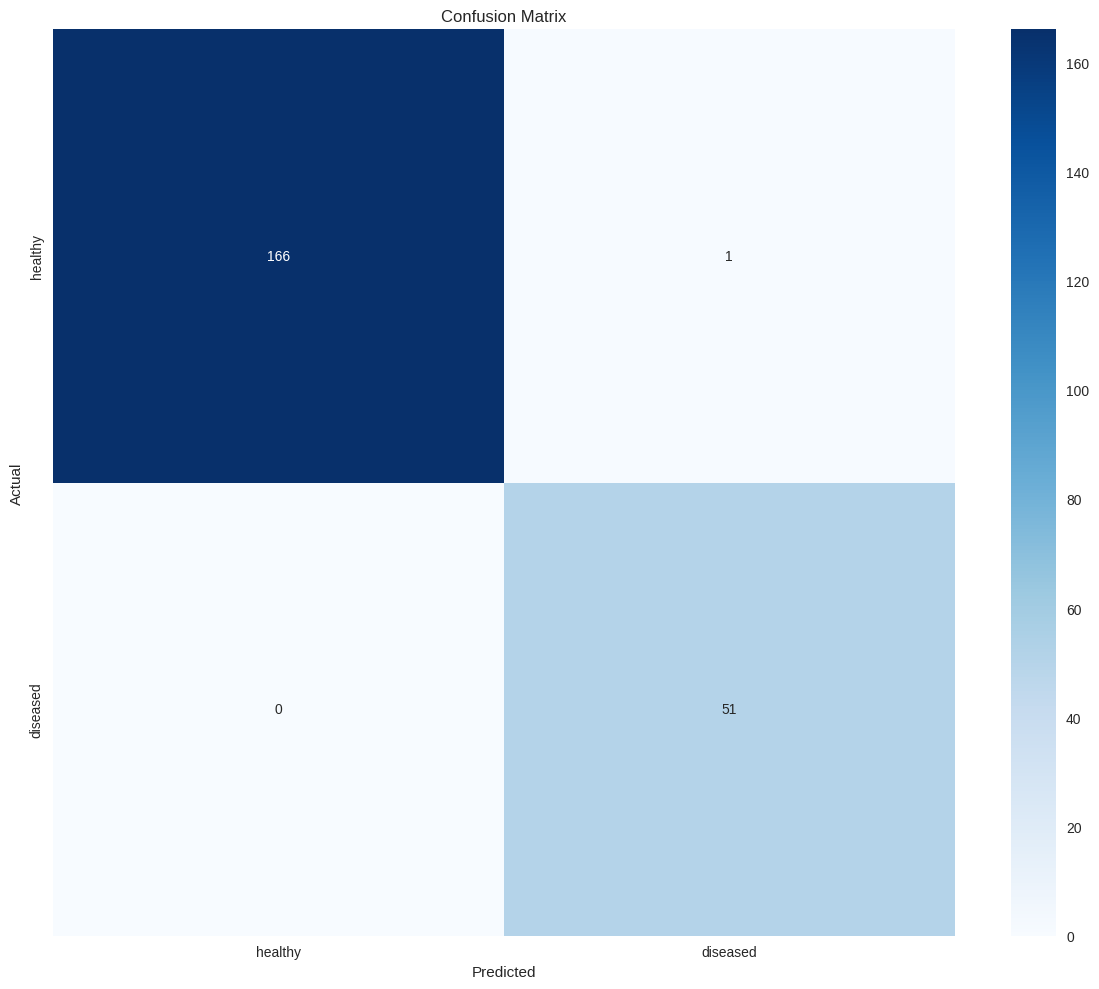

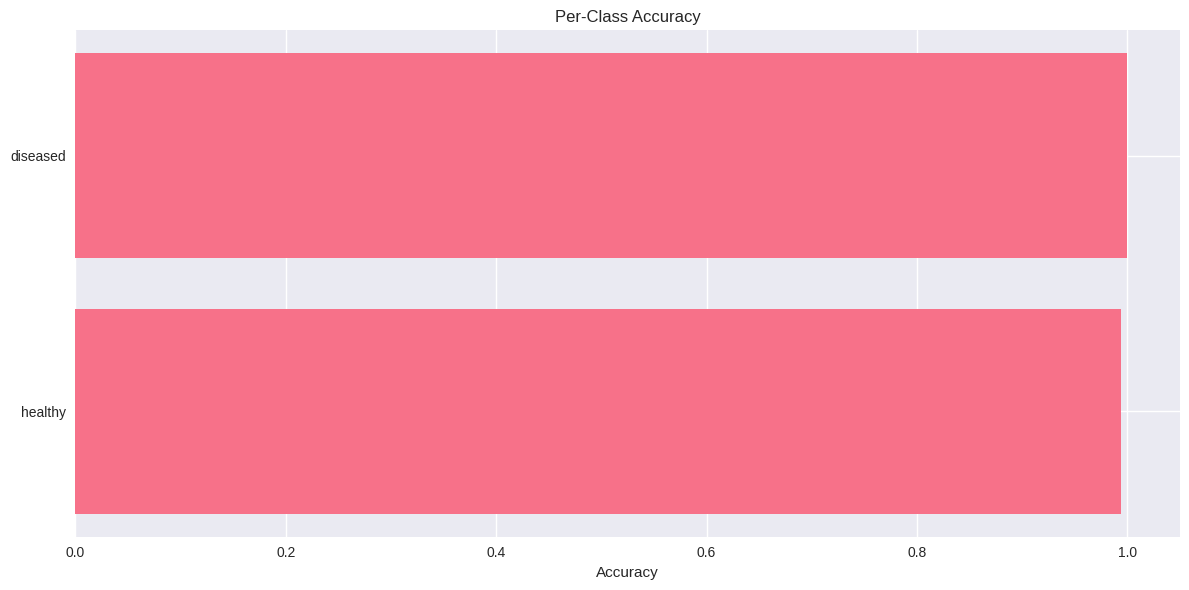

In [13]:
# ============================================
# STEP 4: Comprehensive Model Comparison
# ============================================
# Train CNN and ResNet18, evaluate all with plots, then select best

print(f'\n{"="*60}')
print("COMPREHENSIVE MODEL COMPARISON: CNN vs ResNet18")
print(f'{"="*60}')

# Dictionary to store all model results
all_model_results = {}

# ========== MODEL 1: Simple CNN ==========
print("\n" + "="*60)
print("[1/3] TRAINING SIMPLE CNN")
print("="*60)

cnn_model = SimpleCNN(num_classes=2).to(device)
cnn_results = train_baseline_model(
    cnn_model, train_loader, val_loader, device, "Simple CNN", epochs=50
)

print(f"\n✓ CNN - Best Validation Accuracy: {cnn_results['best_val_acc']:.2f}%")

# Evaluate CNN on test set
cnn_model.eval()
cnn_test_preds = []
cnn_test_labels = []
cnn_test_probs = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = cnn_model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        cnn_test_preds.extend(predicted.cpu().numpy())
        cnn_test_labels.extend(labels.cpu().numpy())
        cnn_test_probs.extend(probs.cpu().numpy())

cnn_test_acc = accuracy_score(cnn_test_labels, cnn_test_preds)
print(f"✓ CNN - Test Accuracy: {cnn_test_acc:.2%}")

# Evaluate CNN with plots
print(f"\n{'='*60}")
print("CNN EVALUATION PLOTS")
print(f"{'='*60}")
cnn_evaluator = ModelEvaluator(cnn_model, test_loader, device, health_classes)
cnn_test_preds_eval, cnn_test_labels_eval, cnn_test_probs_eval = cnn_evaluator.evaluate()

# Plot confusion matrix
cnn_evaluator.plot_confusion_matrix(cnn_test_labels_eval, cnn_test_preds_eval)

# Per-class accuracy
cnn_class_accs = cnn_evaluator.per_class_accuracy(cnn_test_labels_eval, cnn_test_preds_eval)

# Store CNN results
all_model_results['Simple_CNN'] = {
    'model': cnn_model,
    'val_acc': cnn_results['best_val_acc'],
    'test_acc': cnn_test_acc,
    'test_preds': np.array(cnn_test_preds_eval),
    'test_labels': np.array(cnn_test_labels_eval),
    'class_accs': cnn_class_accs,
    'train_losses': cnn_results['train_losses'],
    'val_losses': cnn_results['val_losses'],
    'train_accs': cnn_results['train_accs'],
    'val_accs': cnn_results['val_accs']
}


[2/3] TRAINING RESNET18
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 129MB/s]


ResNet18 - Epoch 5/50: Train Acc: 98.20%, Val Acc: 100.00%
ResNet18 - Epoch 10/50: Train Acc: 99.43%, Val Acc: 100.00%
ResNet18 - Epoch 15/50: Train Acc: 99.34%, Val Acc: 100.00%
ResNet18 - Epoch 20/50: Train Acc: 99.24%, Val Acc: 100.00%
ResNet18 - Epoch 25/50: Train Acc: 99.81%, Val Acc: 100.00%
ResNet18 - Epoch 30/50: Train Acc: 100.00%, Val Acc: 100.00%
ResNet18 - Epoch 35/50: Train Acc: 99.81%, Val Acc: 100.00%
ResNet18 - Epoch 40/50: Train Acc: 99.81%, Val Acc: 100.00%
ResNet18 - Epoch 45/50: Train Acc: 99.81%, Val Acc: 100.00%
ResNet18 - Epoch 50/50: Train Acc: 100.00%, Val Acc: 100.00%

✓ ResNet18 - Best Validation Accuracy: 100.00%
✓ ResNet18 - Test Accuracy: 100.00%

RESNET18 EVALUATION PLOTS


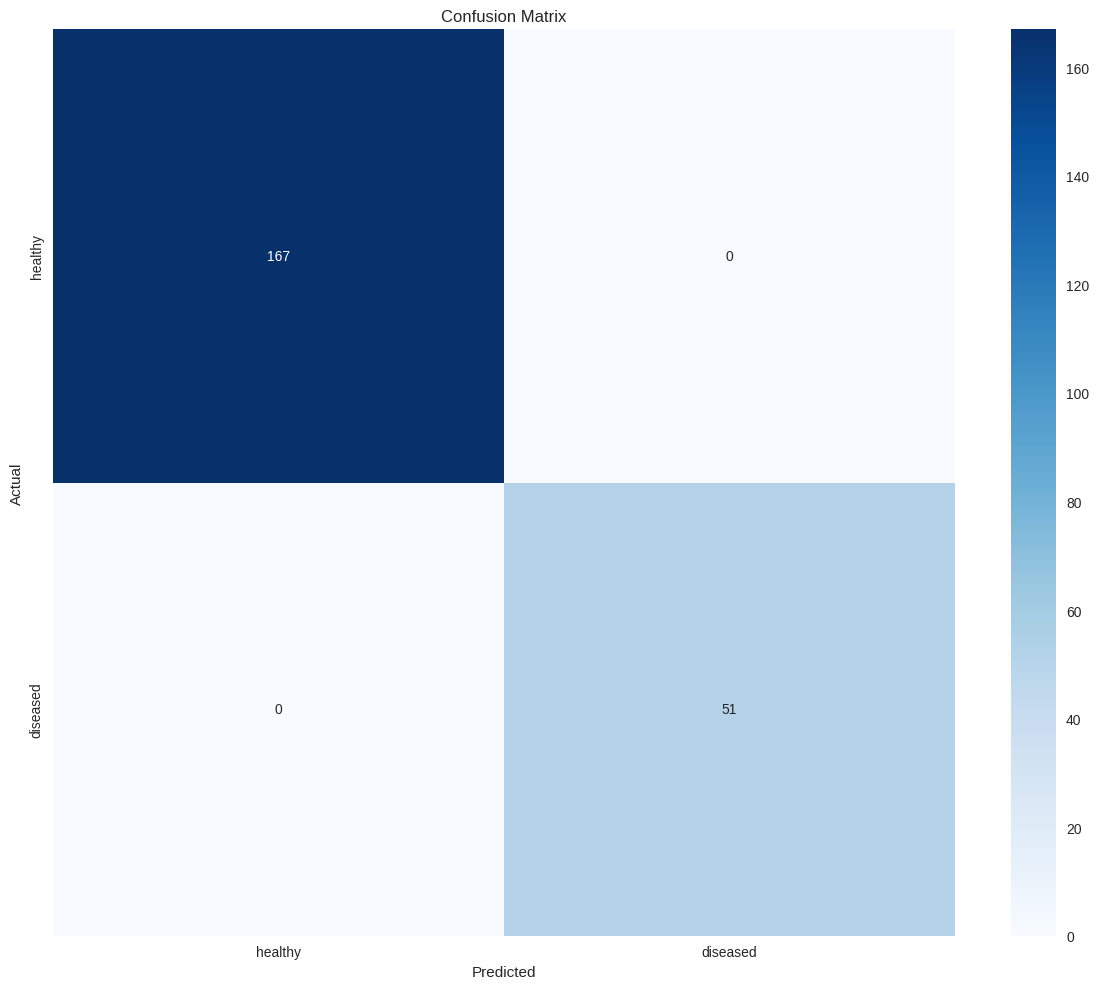

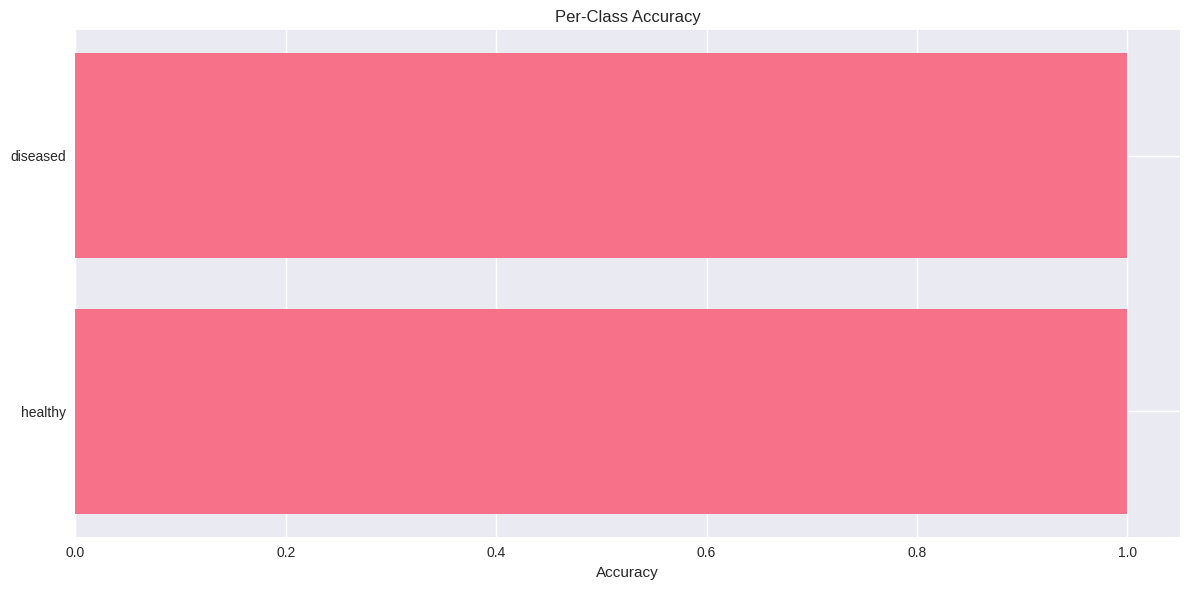

In [14]:

# ========== MODEL 2: ResNet18 ==========
print("\n" + "="*60)
print("[2/3] TRAINING RESNET18")
print("="*60)

resnet18_model = BaselineResNet18(num_classes=2, pretrained=True).to(device)
resnet18_results = train_baseline_model(
    resnet18_model, train_loader, val_loader, device, "ResNet18", epochs=50
)

print(f"\n✓ ResNet18 - Best Validation Accuracy: {resnet18_results['best_val_acc']:.2f}%")

# Evaluate ResNet18 on test set
resnet18_model.eval()
resnet18_test_preds = []
resnet18_test_labels = []
resnet18_test_probs = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet18_model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        resnet18_test_preds.extend(predicted.cpu().numpy())
        resnet18_test_labels.extend(labels.cpu().numpy())
        resnet18_test_probs.extend(probs.cpu().numpy())

resnet18_test_acc = accuracy_score(resnet18_test_labels, resnet18_test_preds)
print(f"✓ ResNet18 - Test Accuracy: {resnet18_test_acc:.2%}")

# Evaluate ResNet18 with plots
print(f"\n{'='*60}")
print("RESNET18 EVALUATION PLOTS")
print(f"{'='*60}")
resnet18_evaluator = ModelEvaluator(resnet18_model, test_loader, device, health_classes)
resnet18_test_preds_eval, resnet18_test_labels_eval, resnet18_test_probs_eval = resnet18_evaluator.evaluate()

# Plot confusion matrix
resnet18_evaluator.plot_confusion_matrix(resnet18_test_labels_eval, resnet18_test_preds_eval)

# Per-class accuracy
resnet18_class_accs = resnet18_evaluator.per_class_accuracy(resnet18_test_labels_eval, resnet18_test_preds_eval)

# Store ResNet18 results
all_model_results['ResNet18'] = {
    'model': resnet18_model,
    'val_acc': resnet18_results['best_val_acc'],
    'test_acc': resnet18_test_acc,
    'test_preds': np.array(resnet18_test_preds_eval),
    'test_labels': np.array(resnet18_test_labels_eval),
    'class_accs': resnet18_class_accs,
    'train_losses': resnet18_results['train_losses'],
    'val_losses': resnet18_results['val_losses'],
    'train_accs': resnet18_results['train_accs'],
    'val_accs': resnet18_results['val_accs']
}



COMPREHENSIVE MODEL COMPARISON

[1/4] Training History Comparison...


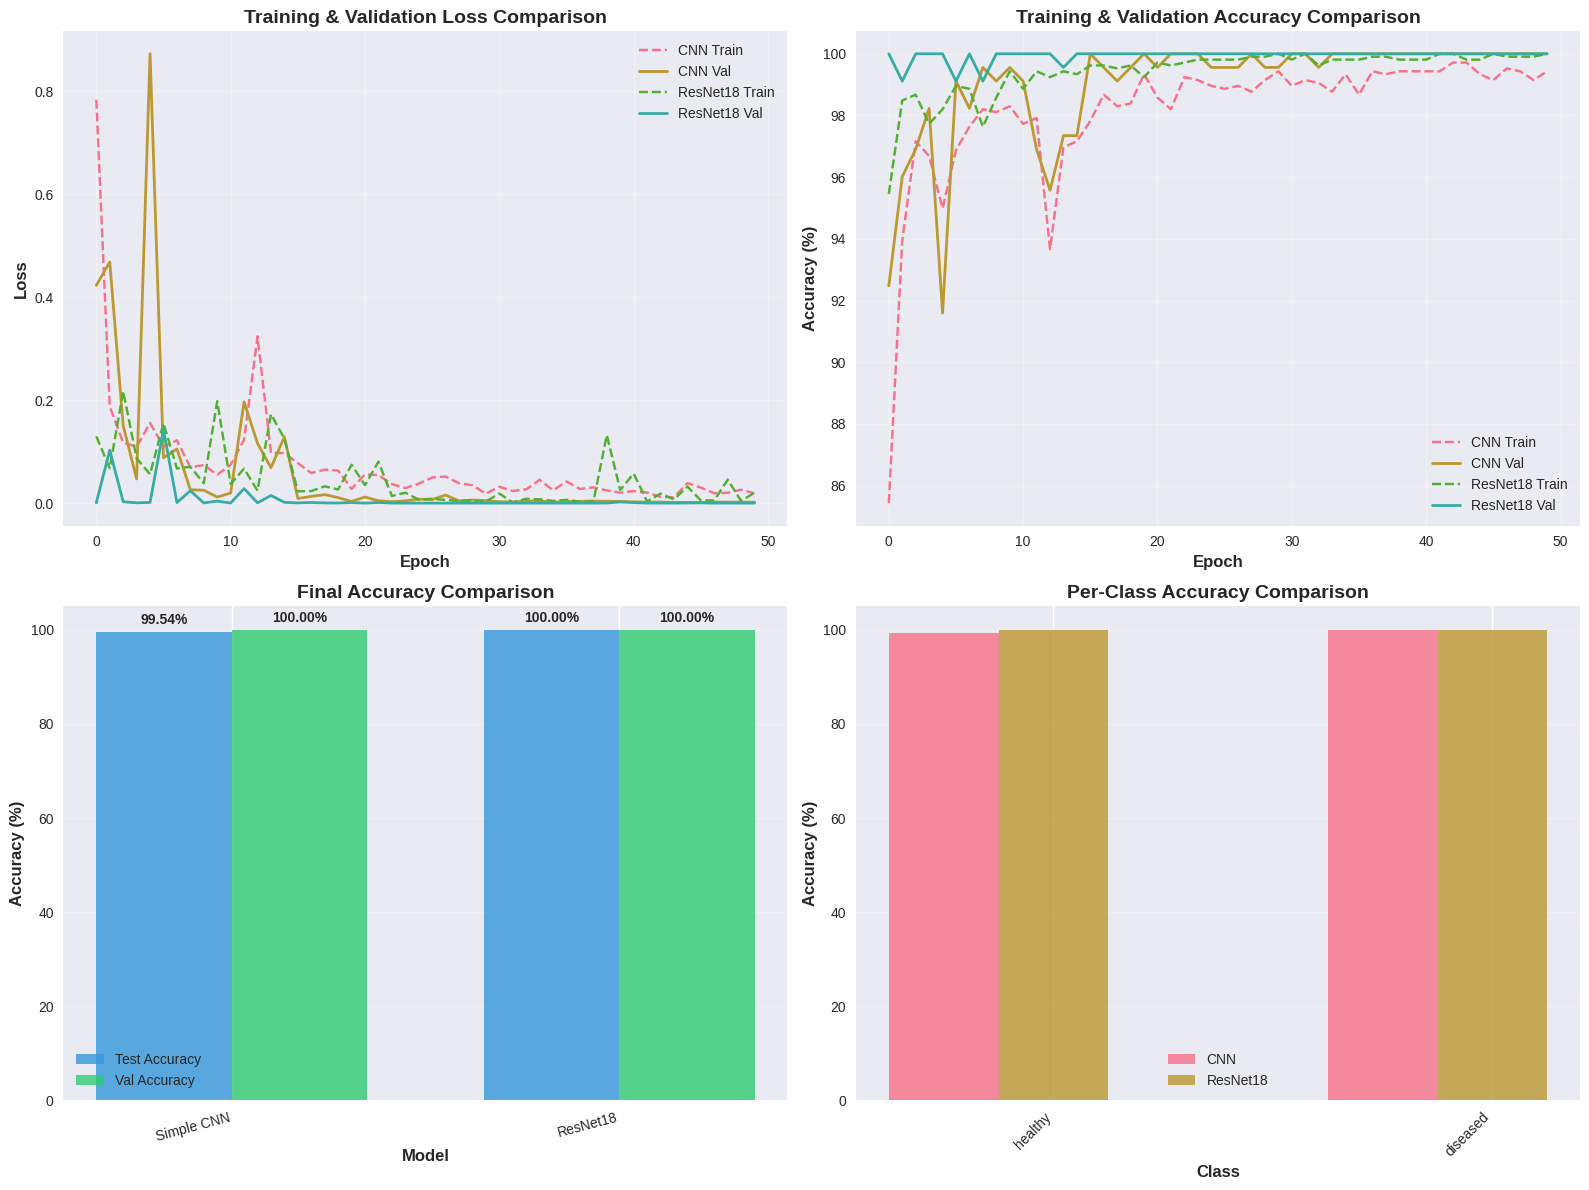


[2/4] Detailed Metrics Comparison...

DETAILED METRICS COMPARISON
     Model Val Accuracy (%) Test Accuracy (%) Precision Recall F1-Score
Simple CNN           100.00             99.54    0.9955 0.9954   0.9954
  ResNet18           100.00            100.00    1.0000 1.0000   1.0000

[3/4] Selecting Best Model...

BEST MODEL SELECTION

Model Scores (considering accuracy, generalization, complexity):
  ✓ Simple CNN     : 1.0954 (Test: 99.54%, Val: 100.00%)
    ResNet18       : 1.0900 (Test: 100.00%, Val: 100.00%)

✓ BEST MODEL: Simple CNN
  - Test Accuracy: 0.9954 (99.54%)
  - Validation Accuracy: 100.00%
  - Final Score: 1.0954

[4/4] Saving Best Model...
✓ Best model saved to models/best_health_model.pth

✓ Model variable updated to best model: Simple CNN


In [15]:
# ========== COMPREHENSIVE COMPARISON ==========
print(f"\n{'='*60}")
print("COMPREHENSIVE MODEL COMPARISON")
print(f"{'='*60}")

# 1. Training History Comparison
print("\n[1/4] Training History Comparison...")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Loss comparison
axes[0, 0].plot(all_model_results['Simple_CNN']['train_losses'], label='CNN Train', linestyle='--')
axes[0, 0].plot(all_model_results['Simple_CNN']['val_losses'], label='CNN Val', linewidth=2)
axes[0, 0].plot(all_model_results['ResNet18']['train_losses'], label='ResNet18 Train', linestyle='--')
axes[0, 0].plot(all_model_results['ResNet18']['val_losses'], label='ResNet18 Val', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Training & Validation Loss Comparison', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Accuracy comparison
axes[0, 1].plot(all_model_results['Simple_CNN']['train_accs'], label='CNN Train', linestyle='--')
axes[0, 1].plot(all_model_results['Simple_CNN']['val_accs'], label='CNN Val', linewidth=2)
axes[0, 1].plot(all_model_results['ResNet18']['train_accs'], label='ResNet18 Train', linestyle='--')
axes[0, 1].plot(all_model_results['ResNet18']['val_accs'], label='ResNet18 Val', linewidth=2)
axes[0, 1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Training & Validation Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Test Accuracy Comparison
models = ['Simple CNN', 'ResNet18']
test_accs = [
    all_model_results['Simple_CNN']['test_acc'],
    all_model_results['ResNet18']['test_acc'],
]
val_accs = [
    all_model_results['Simple_CNN']['val_acc'],
    all_model_results['ResNet18']['val_acc'],
]

x = np.arange(len(models))
width = 0.35
axes[1, 0].bar(x - width/2, [acc*100 for acc in test_accs], width, label='Test Accuracy', color='#3498db', alpha=0.8)
axes[1, 0].bar(x + width/2, val_accs, width, label='Val Accuracy', color='#2ecc71', alpha=0.8)
axes[1, 0].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Final Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models, rotation=15, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)
# Add value labels
for i, (test_acc, val_acc) in enumerate(zip(test_accs, val_accs)):
    axes[1, 0].text(i - width/2, test_acc*100 + 1, f'{test_acc*100:.2f}%', ha='center', va='bottom', fontweight='bold')
    axes[1, 0].text(i + width/2, val_acc + 1, f'{val_acc:.2f}%', ha='center', va='bottom', fontweight='bold')

# Per-Class Accuracy Comparison
class_names = list(health_classes)
cnn_class_accs_list = [all_model_results['Simple_CNN']['class_accs'].get(cls, 0) for cls in class_names]
r18_class_accs_list = [all_model_results['ResNet18']['class_accs'].get(cls, 0) for cls in class_names]

x_class = np.arange(len(class_names))
width_class = 0.25
axes[1, 1].bar(x_class - width_class, [acc*100 for acc in cnn_class_accs_list], width_class, label='CNN', alpha=0.8)
axes[1, 1].bar(x_class, [acc*100 for acc in r18_class_accs_list], width_class, label='ResNet18', alpha=0.8)
axes[1, 1].set_xlabel('Class', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Per-Class Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(x_class)
axes[1, 1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].set_ylim([0, 105])

plt.tight_layout()
plt.show()

# 2. Detailed Metrics Table
print("\n[2/4] Detailed Metrics Comparison...")
from sklearn.metrics import precision_score, recall_score, f1_score

comparison_data = []
for model_name, results in all_model_results.items():
    y_true = results['test_labels']
    y_pred = results['test_preds']

    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    comparison_data.append({
        'Model': model_name.replace('_', ' '),
        'Val Accuracy (%)': f"{results['val_acc']:.2f}",
        'Test Accuracy (%)': f"{results['test_acc']*100:.2f}",
        'Precision': f"{precision:.4f}",
        'Recall': f"{recall:.4f}",
        'F1-Score': f"{f1:.4f}"
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("DETAILED METRICS COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# 3. Model Selection
print("\n[3/4] Selecting Best Model...")

# Calculate scores considering multiple factors
MEANINGFUL_DIFF_THRESHOLD = 0.005  # 0.5%

model_scores = {}
for model_name, results in all_model_results.items():
    # Base score from test accuracy
    test_acc_score = results['test_acc']

    # Bonus for validation accuracy (generalization)
    val_acc_bonus = results['val_acc'] / 100.0 * 0.1

    # Penalty for model complexity (simpler is better)
    complexity_penalty = {
        'Simple_CNN': 0.0,  # Simplest
        'ResNet18': 0.01,   # Medium
    }[model_name]

    # Calculate final score
    final_score = test_acc_score + val_acc_bonus - complexity_penalty
    model_scores[model_name] = final_score

# Find best model
best_model_name = max(model_scores, key=model_scores.get)
best_model = all_model_results[best_model_name]['model']
best_test_acc = all_model_results[best_model_name]['test_acc']
best_val_acc = all_model_results[best_model_name]['val_acc']

print(f"\n{'='*60}")
print("BEST MODEL SELECTION")
print(f"{'='*60}")
print(f"\nModel Scores (considering accuracy, generalization, complexity):")
for model_name, score in sorted(model_scores.items(), key=lambda x: x[1], reverse=True):
    marker = "✓" if model_name == best_model_name else " "
    print(f"  {marker} {model_name.replace('_', ' '):15s}: {score:.4f} (Test: {all_model_results[model_name]['test_acc']*100:.2f}%, Val: {all_model_results[model_name]['val_acc']:.2f}%)")

print(f"\n{'='*60}")
print(f"✓ BEST MODEL: {best_model_name.replace('_', ' ')}")
print(f"  - Test Accuracy: {best_test_acc:.4f} ({best_test_acc*100:.2f}%)")
print(f"  - Validation Accuracy: {best_val_acc:.2f}%")
print(f"  - Final Score: {model_scores[best_model_name]:.4f}")
print(f"{'='*60}")

# 4. Save Best Model
print("\n[4/4] Saving Best Model...")
best_model_path = f'{MODEL_DIR}/best_health_model.pth'
torch.save(best_model.state_dict(), best_model_path)
print(f'✓ Best model saved to {best_model_path}')

# Update model reference for further evaluation
model = best_model
print(f"\n✓ Model variable updated to best model: {best_model_name.replace('_', ' ')}")
print(f"{'='*60}")


In [16]:
# ========== STEP 7: Statistical Testing and Bias/Fairness Analysis ==========
print(f"\n{'='*60}")
print("STATISTICAL TESTING AND BIAS/FAIRNESS ANALYSIS")
print(f"{'='*60}")

# Ensure test_dataset exists for statistical analysis
if 'test_dataset' not in locals():
    test_dataset = PlantDataset(data_dir='data/test', transform=get_transforms(mode='val'), mode='health')

# Get predictions and labels from best model
best_model_test_preds = all_model_results[best_model_name]['test_preds']
best_model_test_labels = all_model_results[best_model_name]['test_labels']

# Initialize statistical analyzer with best model
stat_analyzer = StatisticalAnalyzer(model, test_loader, test_dataset, device, health_classes)

# Calculate confidence interval for best model
test_accuracy = accuracy_score(best_model_test_labels, best_model_test_preds)
n_samples = len(best_model_test_labels)
ci_lower, ci_upper = stat_analyzer.calculate_confidence_interval(test_accuracy, n_samples)

print(f"\nStatistical Validation:")
print(f"  - Best Model: {best_model_name.replace('_', ' ')}")
print(f"  - Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  - 95% Confidence Interval: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"  - Sample Size: {n_samples}")

# Compare all models with McNemar's test (if multiple models)
if len(all_model_results) > 1:
    print(f"\nModel Comparison (McNemar's Test):")
    print(f"Comparing all models pairwise...")

    model_names = list(all_model_results.keys())
    for i in range(len(model_names)):
        for j in range(i+1, len(model_names)):
            model1_name = model_names[i]
            model2_name = model_names[j]

            y_true = all_model_results[model1_name]['test_labels']
            y_pred1 = all_model_results[model1_name]['test_preds']
            y_pred2 = all_model_results[model2_name]['test_preds']

            mcnemar_result = stat_analyzer.mcnemar_test(y_true, y_pred1, y_pred2)

            print(f"\n  {model1_name.replace('_', ' ')} vs {model2_name.replace('_', ' ')}:")
            print(f"    - Test Statistic: {mcnemar_result['statistic']:.4f}")
            print(f"    - p-value: {mcnemar_result['p_value']:.4f}")

            if mcnemar_result['p_value'] < 0.05:
                acc1 = np.mean(y_pred1 == y_true)
                acc2 = np.mean(y_pred2 == y_true)
                if acc1 > acc2:
                    print(f"    → {model1_name.replace('_', ' ')} is significantly better (p < 0.05)")
                else:
                    print(f"    → {model2_name.replace('_', ' ')} is significantly better (p < 0.05)")
            else:
                print(f"    → No statistically significant difference (p >= 0.05)")

# Bias and Fairness Analysis
print(f"\nBias and Fairness Audit:")
fairness_metrics = stat_analyzer.fairness_metrics(best_model_test_labels, best_model_test_preds)
print(f"  - Healthy TPR (Sensitivity): {fairness_metrics['healthy_tpr']:.4f}")
print(f"  - Diseased TPR (Sensitivity): {fairness_metrics['diseased_tpr']:.4f}")
print(f"  - Healthy FPR: {fairness_metrics['healthy_fpr']:.4f}")
print(f"  - Diseased FPR: {fairness_metrics['diseased_fpr']:.4f}")
print(f"  - Demographic Parity Difference: {fairness_metrics['demographic_parity_difference']:.4f}")
print(f"  - Equalized Odds Difference: {fairness_metrics['equalized_odds_difference']:.4f}")

# Per-species performance analysis
print(f"\nPer-Species Performance Analysis:")
species_perf = stat_analyzer.analyze_species_performance()
print(f"  - Analyzed {len(species_perf)} plant species")
if species_perf:
    sorted_species = sorted(species_perf.items(), key=lambda x: x[1]['overall_accuracy'])
    print(f"\n  Top 3 Performing Species:")
    for species, metrics in sorted_species[-3:]:
        print(f"    - {species}: {metrics['overall_accuracy']:.4f} ({metrics['total_samples']} samples)")
    print(f"\n  Bottom 3 Performing Species:")
    for species, metrics in sorted_species[:3]:
        print(f"    - {species}: {metrics['overall_accuracy']:.4f} ({metrics['total_samples']} samples)")

# Generate comprehensive statistical report
print(f"\nGenerating comprehensive statistical report...")
stat_report = stat_analyzer.generate_statistical_report(best_model_test_labels, best_model_test_preds)
print(f"  ✓ Statistical report generated")
print(f"  - Accuracy: {stat_report['accuracy']:.4f}")
print(f"  - Confidence Interval: {stat_report['confidence_interval_95']}")

# Model Selection Recommendation
print(f"\n{'='*60}")
print("MODEL SELECTION RECOMMENDATION")
print(f"{'='*60}")

print(f"\nModel Performance Summary:")
for model_name, results in all_model_results.items():
    marker = "✓" if model_name == best_model_name else " "
    print(f"  {marker} {model_name.replace('_', ' '):15s}: Test Acc: {results['test_acc']*100:.2f}%, Val Acc: {results['val_acc']:.2f}%")

accuracy_diff = max([r['test_acc'] for r in all_model_results.values()]) - min([r['test_acc'] for r in all_model_results.values()])

if accuracy_diff < 0.001:
    print(f"\n✓ Recommendation: All models perform equally well")
    print(f"  → Choose {best_model_name.replace('_', ' ')} - selected based on complexity and generalization")
elif all_model_results[best_model_name]['test_acc'] == max([r['test_acc'] for r in all_model_results.values()]):
    print(f"\n✓ Recommendation: {best_model_name.replace('_', ' ')} is the best choice")
    print(f"  → Highest test accuracy: {best_test_acc*100:.2f}%")
    print(f"  → Best validation accuracy: {best_val_acc:.2f}%")
    print(f"  → Optimal balance of performance and complexity")
else:
    print(f"\n✓ Recommendation: {best_model_name.replace('_', ' ')} selected")
    print(f"  → Best overall score considering accuracy, generalization, and complexity")

print(f"\nNote: Best model has been saved and is ready for deployment.")
print(f"{'='*60}")



STATISTICAL TESTING AND BIAS/FAIRNESS ANALYSIS

Statistical Validation:
  - Best Model: Simple CNN
  - Test Accuracy: 0.9954 (99.54%)
  - 95% Confidence Interval: [0.9864, 1.0044]
  - Sample Size: 218

Model Comparison (McNemar's Test):
Comparing all models pairwise...

  Simple CNN vs ResNet18:
    - Test Statistic: 1.0000
    - p-value: 0.3173
    → No statistically significant difference (p >= 0.05)

Bias and Fairness Audit:
  - Healthy TPR (Sensitivity): 0.9940
  - Diseased TPR (Sensitivity): 1.0000
  - Healthy FPR: 0.0060
  - Diseased FPR: 0.0000
  - Demographic Parity Difference: 0.9940
  - Equalized Odds Difference: 0.0120

Per-Species Performance Analysis:
  - Analyzed 4 plant species

  Top 3 Performing Species:
    - Tomato: 1.0000 (18 samples)
    - Corn_(maize): 1.0000 (195 samples)
    - Squash: 1.0000 (4 samples)

  Bottom 3 Performing Species:
    - Pepper,_bell: 0.0000 (1 samples)
    - Tomato: 1.0000 (18 samples)
    - Corn_(maize): 1.0000 (195 samples)

Generating co


ENHANCED STATISTICAL ANALYSIS VISUALIZATIONS

[1/3] Plotting Fairness Metrics...


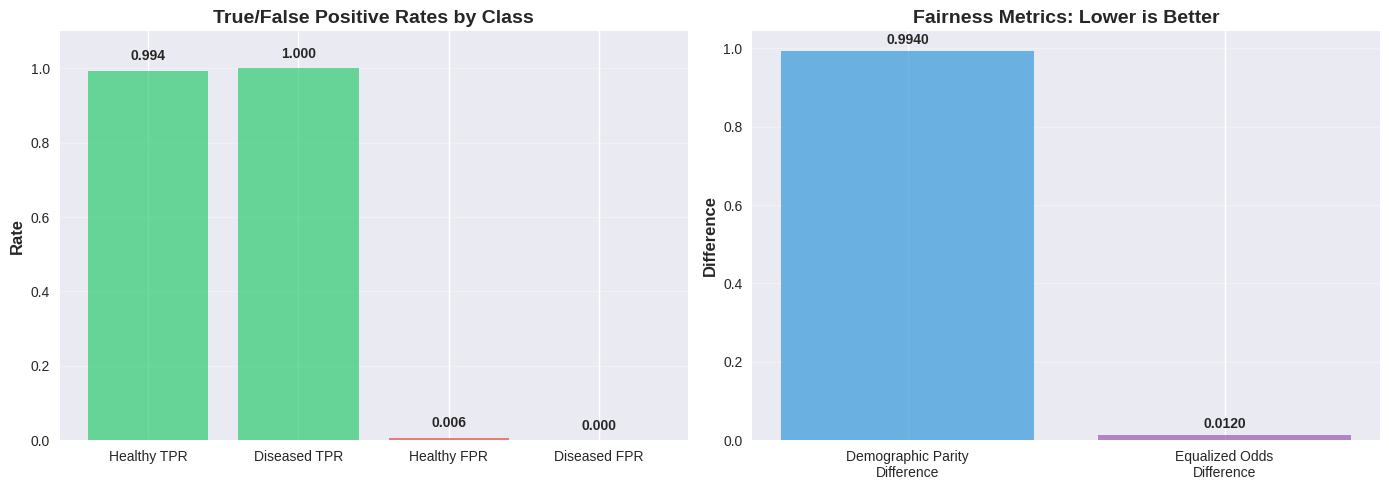


[2/3] Plotting Species Performance Analysis...


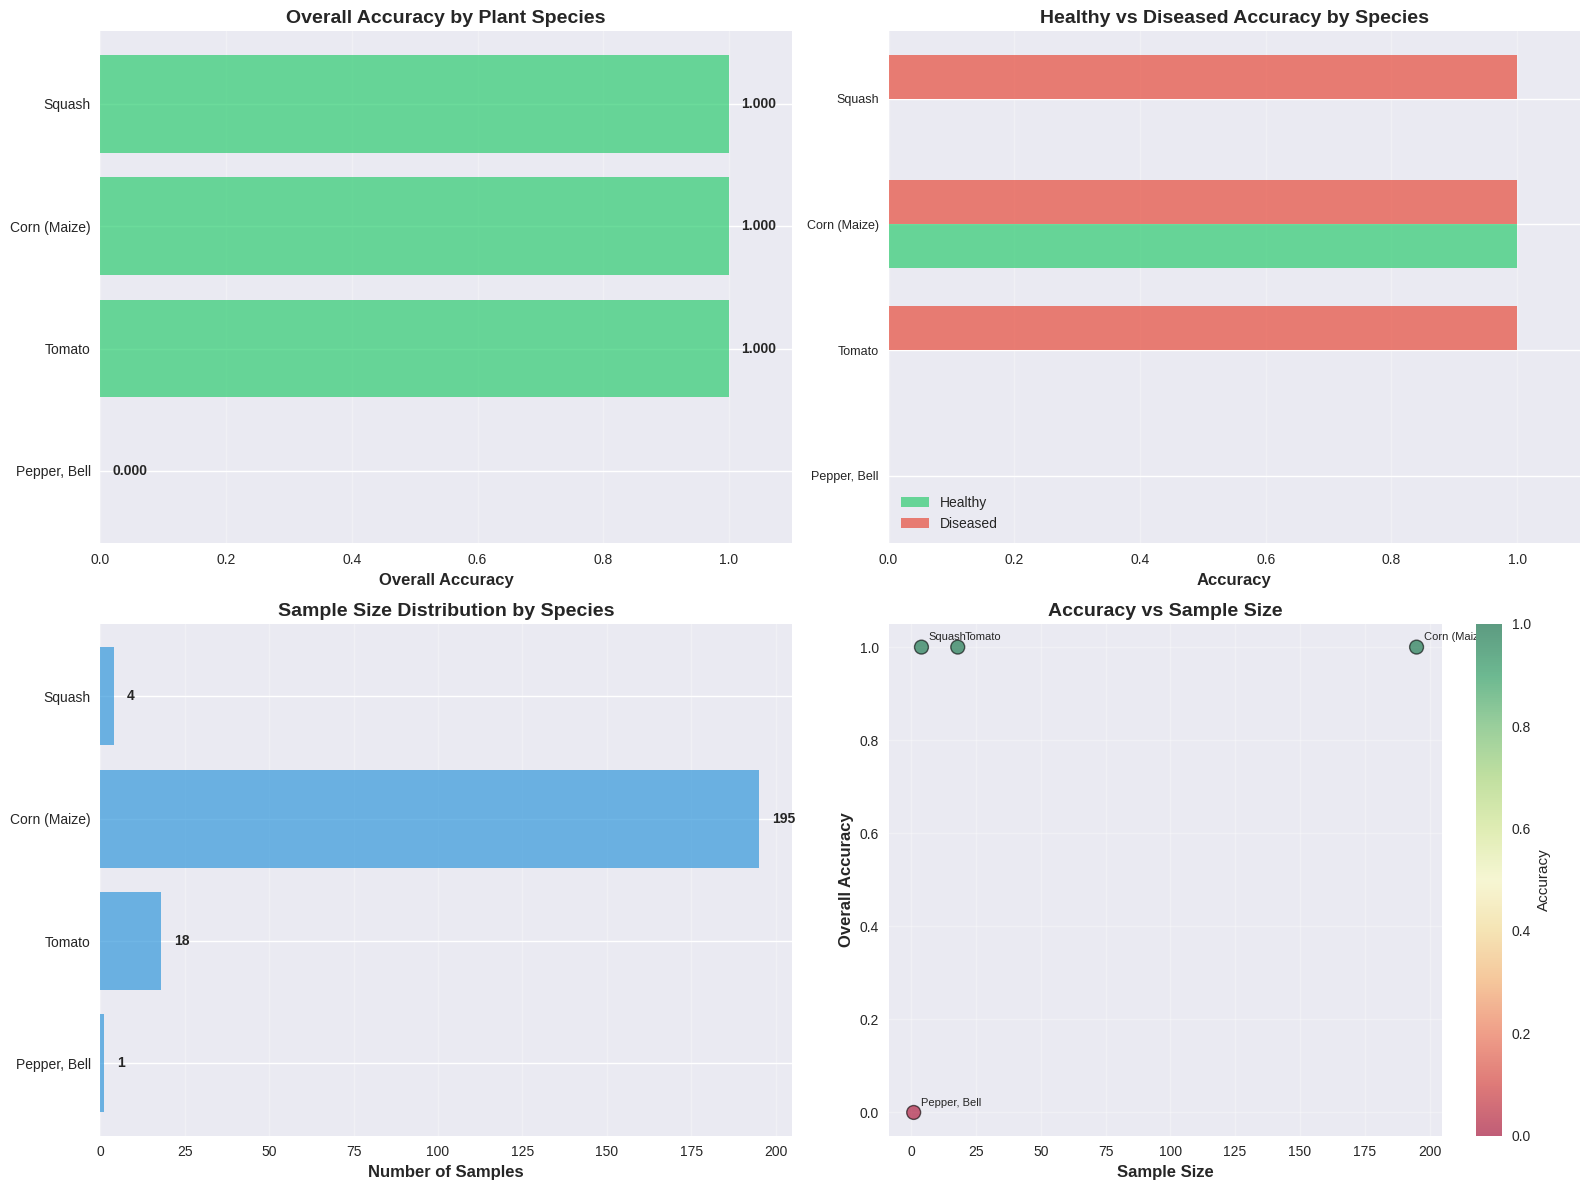


[3/3] Plotting Confidence Intervals for Model Comparison...


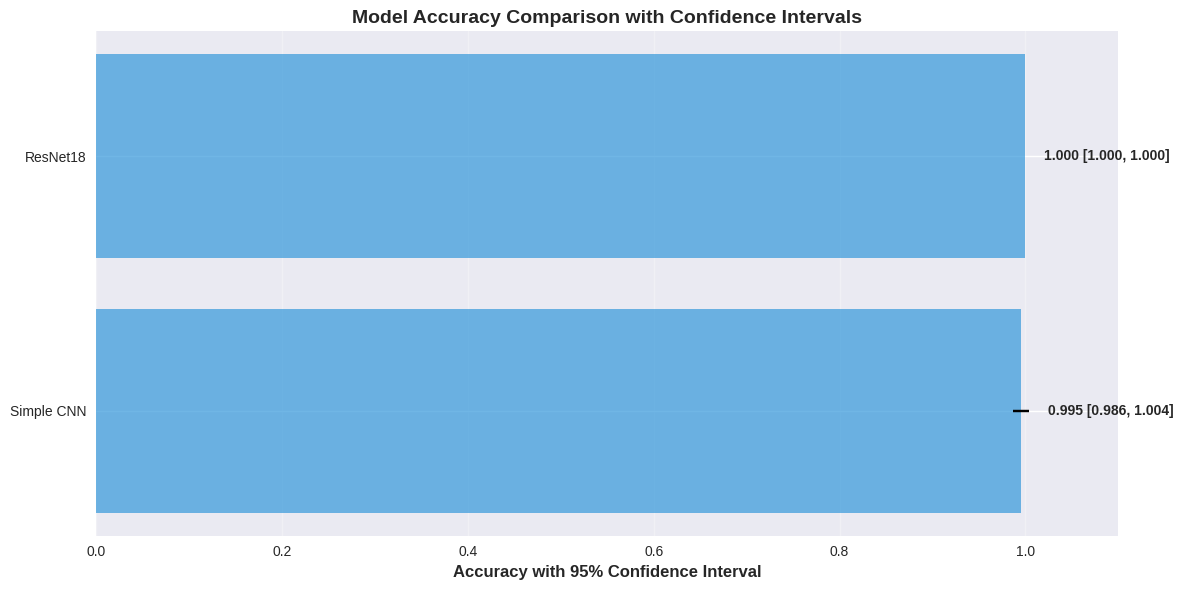


✓ All statistical analysis visualizations completed


In [17]:
# ============================================
# ENHANCED VISUALIZATIONS FOR STATISTICAL ANALYSIS
# ============================================

print(f"\n{'='*60}")
print("ENHANCED STATISTICAL ANALYSIS VISUALIZATIONS")
print(f"{'='*60}")

# Ensure we have the necessary variables
if 'best_model_test_labels' in locals() and 'best_model_test_preds' in locals() and 'stat_analyzer' in locals():

    # 1. Fairness Metrics Visualization
    print("\n[1/3] Plotting Fairness Metrics...")
    fairness = stat_analyzer.fairness_metrics(best_model_test_labels, best_model_test_preds)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # TPR and FPR comparison
    ax1 = axes[0]
    metrics_names = ['Healthy TPR', 'Diseased TPR', 'Healthy FPR', 'Diseased FPR']
    metrics_values = [
        fairness['healthy_tpr'],
        fairness['diseased_tpr'],
        fairness['healthy_fpr'],
        fairness['diseased_fpr']
    ]
    colors = ['#2ecc71', '#2ecc71', '#e74c3c', '#e74c3c']
    bars = ax1.bar(metrics_names, metrics_values, color=colors, alpha=0.7)
    ax1.set_ylabel('Rate', fontsize=12, fontweight='bold')
    ax1.set_title('True/False Positive Rates by Class', fontsize=14, fontweight='bold')
    ax1.set_ylim([0, 1.1])
    ax1.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, metrics_values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

    # Fairness differences
    ax2 = axes[1]
    fairness_names = ['Demographic Parity\nDifference', 'Equalized Odds\nDifference']
    fairness_values = [
        fairness['demographic_parity_difference'],
        fairness['equalized_odds_difference']
    ]
    colors_fair = ['#3498db', '#9b59b6']
    bars2 = ax2.bar(fairness_names, fairness_values, color=colors_fair, alpha=0.7)
    ax2.set_ylabel('Difference', fontsize=12, fontweight='bold')
    ax2.set_title('Fairness Metrics: Lower is Better', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars2, fairness_values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # 2. Species Performance Visualization
    print("\n[2/3] Plotting Species Performance Analysis...")
    species_perf = stat_analyzer.analyze_species_performance()

    if species_perf:
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # Sort species by overall accuracy
        sorted_species = sorted(species_perf.items(), key=lambda x: x[1]['overall_accuracy'])
        species_names = [name.replace('_', ' ').title() for name, _ in sorted_species]

        # Overall accuracy by species
        ax1 = axes[0, 0]
        overall_accs = [metrics['overall_accuracy'] for _, metrics in sorted_species]
        colors = ['#2ecc71' if acc >= 0.95 else '#f39c12' if acc >= 0.85 else '#e74c3c'
                 for acc in overall_accs]
        bars1 = ax1.barh(species_names, overall_accs, color=colors, alpha=0.7)
        ax1.set_xlabel('Overall Accuracy', fontsize=12, fontweight='bold')
        ax1.set_title('Overall Accuracy by Plant Species', fontsize=14, fontweight='bold')
        ax1.set_xlim([0, 1.1])
        ax1.grid(axis='x', alpha=0.3)
        for bar, acc in zip(bars1, overall_accs):
            ax1.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                    f'{acc:.3f}', va='center', fontweight='bold')

        # Healthy vs Diseased accuracy comparison
        ax2 = axes[0, 1]
        healthy_accs = [metrics['healthy_accuracy'] for _, metrics in sorted_species]
        diseased_accs = [metrics['diseased_accuracy'] for _, metrics in sorted_species]
        x_pos = np.arange(len(species_names))
        width = 0.35
        bars2a = ax2.barh(x_pos - width/2, healthy_accs, width, label='Healthy', color='#2ecc71', alpha=0.7)
        bars2b = ax2.barh(x_pos + width/2, diseased_accs, width, label='Diseased', color='#e74c3c', alpha=0.7)
        ax2.set_yticks(x_pos)
        ax2.set_yticklabels(species_names, fontsize=9)
        ax2.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
        ax2.set_title('Healthy vs Diseased Accuracy by Species', fontsize=14, fontweight='bold')
        ax2.set_xlim([0, 1.1])
        ax2.legend()
        ax2.grid(axis='x', alpha=0.3)

        # Sample size distribution
        ax3 = axes[1, 0]
        sample_sizes = [metrics['total_samples'] for _, metrics in sorted_species]
        bars3 = ax3.barh(species_names, sample_sizes, color='#3498db', alpha=0.7)
        ax3.set_xlabel('Number of Samples', fontsize=12, fontweight='bold')
        ax3.set_title('Sample Size Distribution by Species', fontsize=14, fontweight='bold')
        ax3.grid(axis='x', alpha=0.3)
        if sample_sizes:
            for bar, size in zip(bars3, sample_sizes):
                ax3.text(bar.get_width() + max(sample_sizes)*0.02, bar.get_y() + bar.get_height()/2,
                        f'{size}', va='center', fontweight='bold')

        # Accuracy vs Sample Size scatter
        ax4 = axes[1, 1]
        scatter = ax4.scatter(sample_sizes, overall_accs, s=100, alpha=0.6, c=overall_accs,
                            cmap='RdYlGn', edgecolors='black', linewidth=1)
        ax4.set_xlabel('Sample Size', fontsize=12, fontweight='bold')
        ax4.set_ylabel('Overall Accuracy', fontsize=12, fontweight='bold')
        ax4.set_title('Accuracy vs Sample Size', fontsize=14, fontweight='bold')
        ax4.grid(alpha=0.3)
        for i, name in enumerate(species_names):
            ax4.annotate(name, (sample_sizes[i], overall_accs[i]),
                        xytext=(5, 5), textcoords='offset points', fontsize=8)
        plt.colorbar(scatter, ax=ax4, label='Accuracy')

        plt.tight_layout()
        plt.show()

    # 3. Confidence Intervals for All Models
    print("\n[3/3] Plotting Confidence Intervals for Model Comparison...")
    if 'all_model_results' in locals() and len(all_model_results) > 1:
        model_accuracies = {name: results['test_acc'] for name, results in all_model_results.items()}

        fig, ax = plt.subplots(1, 1, figsize=(12, 6))

        model_names = [name.replace('_', ' ') for name in model_accuracies.keys()]
        accs = list(model_accuracies.values())
        n_samples = len(best_model_test_labels)

        ci_lowers = []
        ci_uppers = []
        for acc in accs:
            ci_l, ci_u = stat_analyzer.calculate_confidence_interval(acc, n_samples)
            ci_lowers.append(ci_l)
            ci_uppers.append(ci_u)

        y_pos = np.arange(len(model_names))
        errors = [[acc - ci_l for acc, ci_l in zip(accs, ci_lowers)],
                  [ci_u - acc for acc, ci_u in zip(accs, ci_uppers)]]

        bars = ax.barh(y_pos, accs, xerr=errors, color='#3498db', alpha=0.7, capsize=5)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(model_names)
        ax.set_xlabel('Accuracy with 95% Confidence Interval', fontsize=12, fontweight='bold')
        ax.set_title('Model Accuracy Comparison with Confidence Intervals', fontsize=14, fontweight='bold')
        ax.set_xlim([0, 1.1])
        ax.grid(axis='x', alpha=0.3)

        for i, (bar, acc, ci_l, ci_u) in enumerate(zip(bars, accs, ci_lowers, ci_uppers)):
            ax.text(acc + (ci_u - acc) + 0.02, bar.get_y() + bar.get_height()/2,
                   f'{acc:.3f} [{ci_l:.3f}, {ci_u:.3f}]', va='center', fontweight='bold')

        plt.tight_layout()
        plt.show()

    print(f"\n{'='*60}")
    print("✓ All statistical analysis visualizations completed")
    print(f"{'='*60}")
else:
    print("Please run the statistical analysis cell first to generate the required variables.")


## Best Model Comprehensive Analysis and Visualizations

This section provides comprehensive visualizations and analysis of the best performing model, including:
- Species performance rankings
- Class-wise performance metrics
- Model predictions distribution
- Top and bottom performing species analysis


BEST MODEL COMPREHENSIVE ANALYSIS

Best Model: Simple CNN
Test Accuracy: 99.54%
Validation Accuracy: 100.00%

[1/6] Generating Species Performance Rankings...


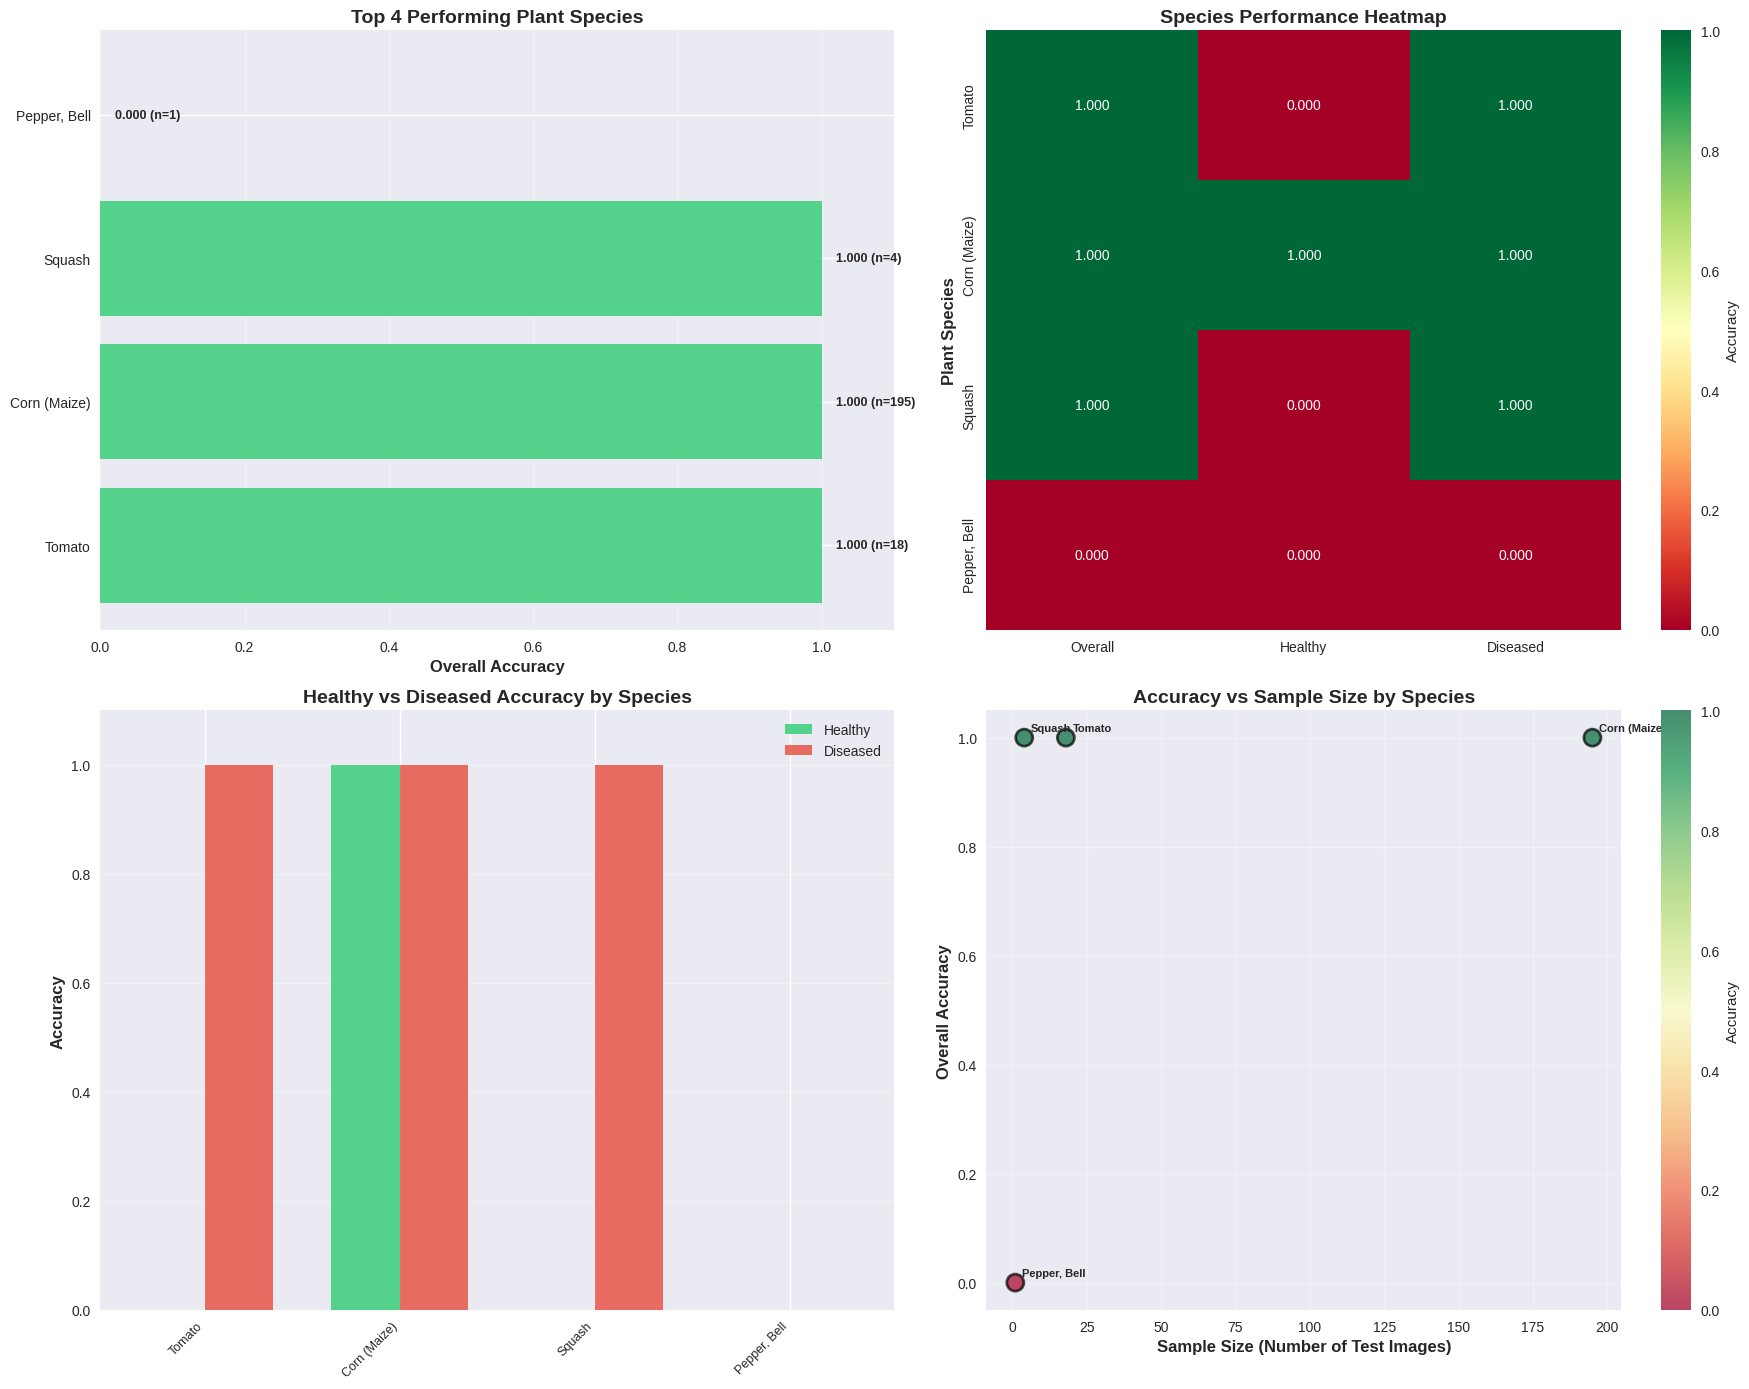


TOP PERFORMING SPECIES
1. Tomato:
   - Overall Accuracy: 1.0000 (100.00%)
   - Healthy Accuracy: 0.0000
   - Diseased Accuracy: 1.0000
   - Total Samples: 18
   - Healthy Samples: 0, Diseased Samples: 18
2. Corn (Maize):
   - Overall Accuracy: 1.0000 (100.00%)
   - Healthy Accuracy: 1.0000
   - Diseased Accuracy: 1.0000
   - Total Samples: 195
   - Healthy Samples: 166, Diseased Samples: 29
3. Squash:
   - Overall Accuracy: 1.0000 (100.00%)
   - Healthy Accuracy: 0.0000
   - Diseased Accuracy: 1.0000
   - Total Samples: 4
   - Healthy Samples: 0, Diseased Samples: 4
4. Pepper, Bell:
   - Overall Accuracy: 0.0000 (0.00%)
   - Healthy Accuracy: 0.0000
   - Diseased Accuracy: 0.0000
   - Total Samples: 1
   - Healthy Samples: 1, Diseased Samples: 0

[2/6] Generating Model Performance Metrics...


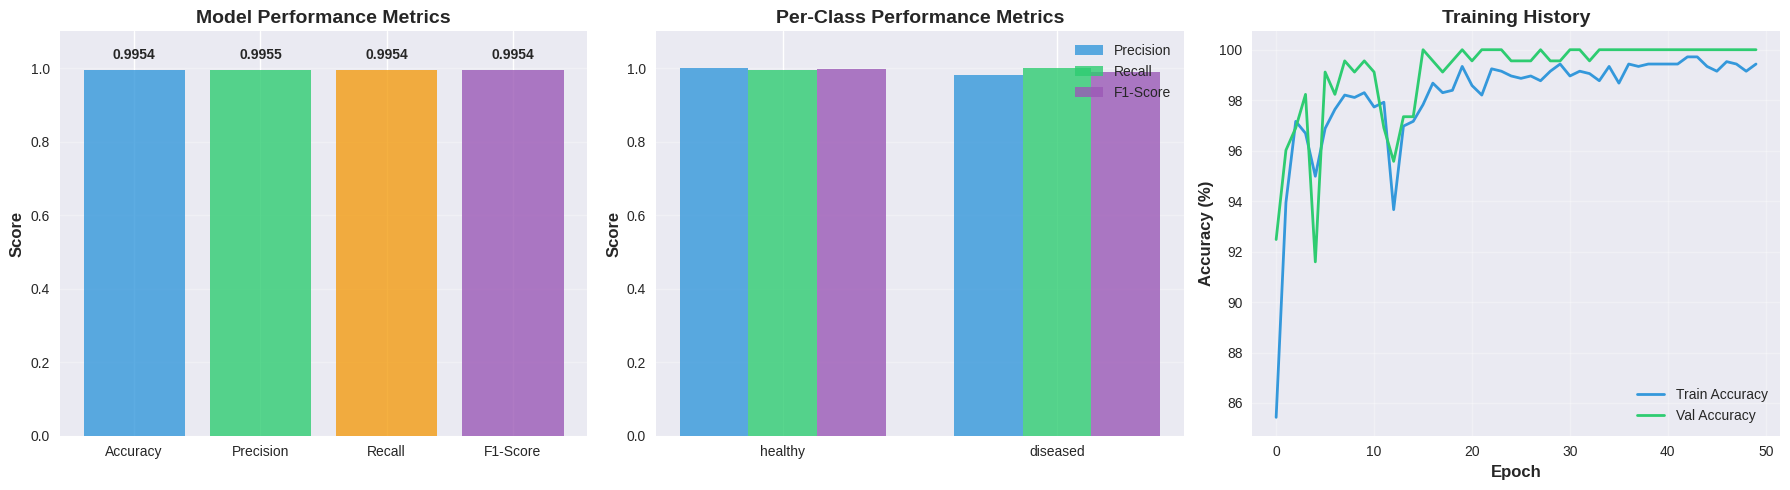


[3/6] Generating Detailed Confusion Matrix...


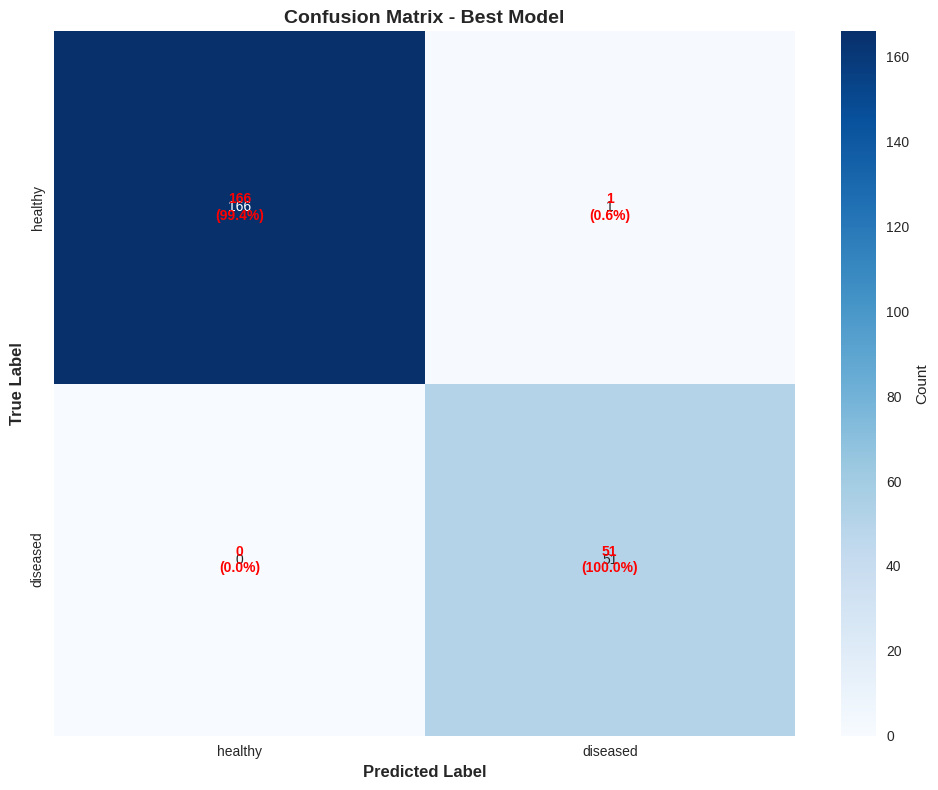


[4/6] Generating Prediction Distribution Analysis...


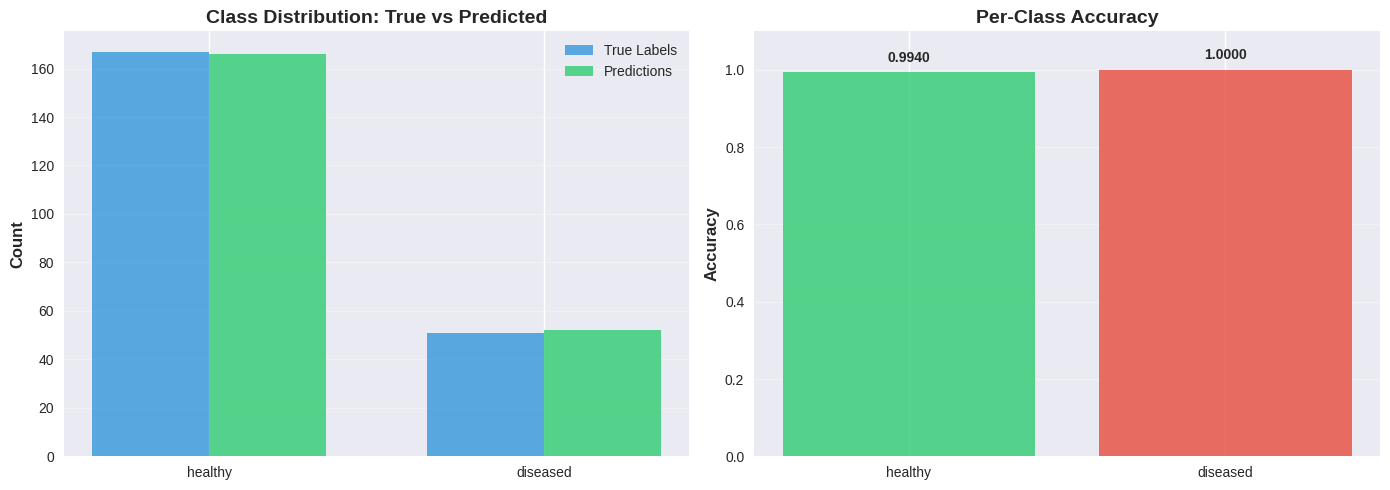


[5/6] Generating Model Comparison Summary...


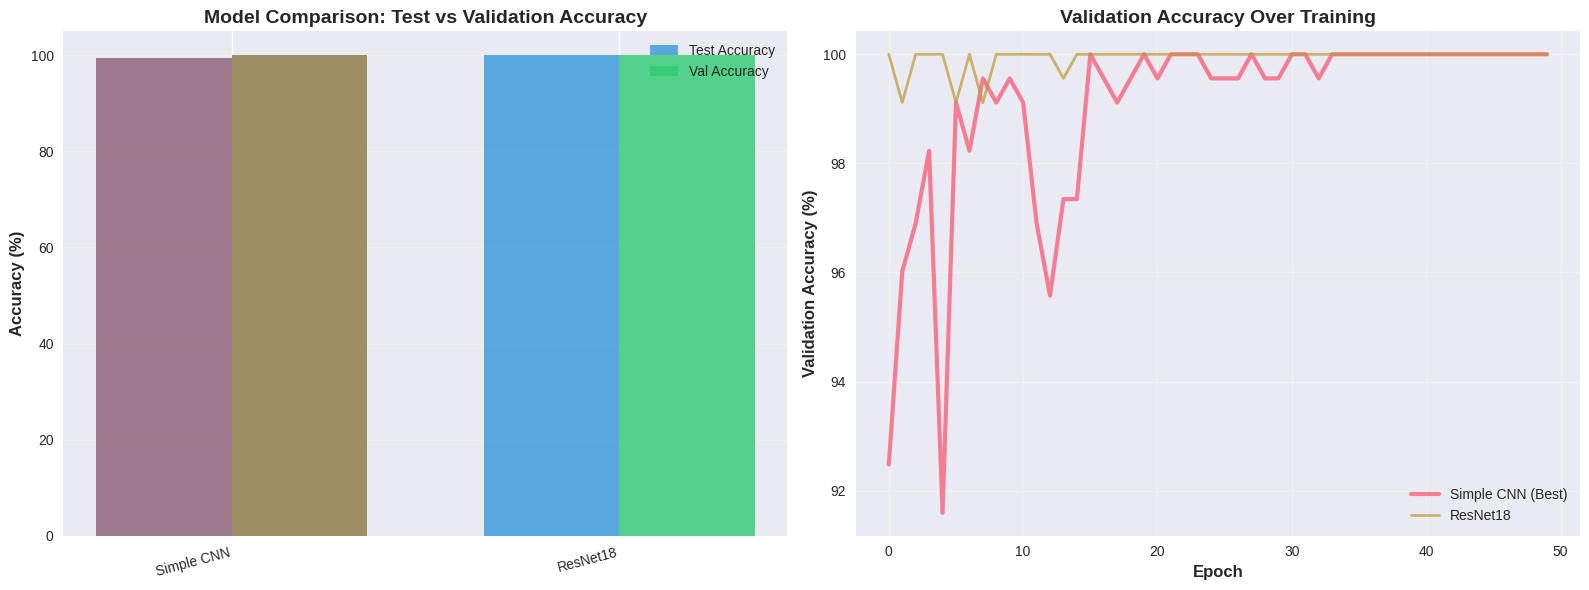


[6/6] Generating Summary Statistics...

BEST MODEL SUMMARY STATISTICS

Model: Simple CNN
Test Accuracy: 99.5413%
Validation Accuracy: 100.0000%

Classification Metrics:
  - Precision (weighted): 0.9955
  - Recall (weighted): 0.9954
  - F1-Score (weighted): 0.9954

Per-Class Metrics:
  Healthy:
    - Precision: 1.0000
    - Recall: 0.9940
    - F1-Score: 0.9970
  Diseased:
    - Precision: 0.9808
    - Recall: 1.0000
    - F1-Score: 0.9903

Total Test Samples: 218
Correct Predictions: 217
Incorrect Predictions: 1

✓ All visualizations and analysis completed!


In [18]:
# ============================================
# COMPREHENSIVE BEST MODEL VISUALIZATION AND ANALYSIS
# ============================================

print("=" * 60)
print("BEST MODEL COMPREHENSIVE ANALYSIS")
print("=" * 60)

# Check if we have the best model results
if 'best_model_name' in locals() and 'all_model_results' in locals() and best_model_name in all_model_results:

    best_results = all_model_results[best_model_name]
    best_model = best_results['model']
    y_true = best_results['test_labels']
    y_pred = best_results['test_preds']

    print(f"\nBest Model: {best_model_name.replace('_', ' ')}")
    print(f"Test Accuracy: {best_results['test_acc']*100:.2f}%")
    print(f"Validation Accuracy: {best_results['val_acc']:.2f}%")

    # Get species performance
    if 'test_dataset' in locals() and 'stat_analyzer' in locals():
        species_perf = stat_analyzer.analyze_species_performance()

        # ============================================
        # VISUALIZATION 1: Species Performance Ranking
        # ============================================
        print("\n[1/6] Generating Species Performance Rankings...")

        if species_perf:
            fig, axes = plt.subplots(2, 2, figsize=(18, 14))

            # Sort species by overall accuracy
            sorted_species = sorted(species_perf.items(), key=lambda x: x[1]['overall_accuracy'], reverse=True)
            species_names = [name.replace('_', ' ').title() for name, _ in sorted_species]

            # 1. Top Performing Species (Bar Chart)
            ax1 = axes[0, 0]
            top_n = min(10, len(sorted_species))
            top_species = sorted_species[:top_n]
            top_names = [name.replace('_', ' ').title() for name, _ in top_species]
            top_accs = [metrics['overall_accuracy'] for _, metrics in top_species]
            top_samples = [metrics['total_samples'] for _, metrics in top_species]

            colors = ['#2ecc71' if acc >= 0.95 else '#f39c12' if acc >= 0.85 else '#e74c3c'
                     for acc in top_accs]
            bars1 = ax1.barh(range(len(top_names)), top_accs, color=colors, alpha=0.8)
            ax1.set_yticks(range(len(top_names)))
            ax1.set_yticklabels(top_names)
            ax1.set_xlabel('Overall Accuracy', fontsize=12, fontweight='bold')
            ax1.set_title(f'Top {top_n} Performing Plant Species', fontsize=14, fontweight='bold')
            ax1.set_xlim([0, 1.1])
            ax1.grid(axis='x', alpha=0.3)
            # Add value labels
            for i, (bar, acc, samples) in enumerate(zip(bars1, top_accs, top_samples)):
                ax1.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                        f'{acc:.3f} (n={samples})', va='center', fontweight='bold', fontsize=9)

            # 2. Species Performance Heatmap
            ax2 = axes[0, 1]
            species_list = [name.replace('_', ' ').title() for name, _ in sorted_species]
            metrics_matrix = []
            for _, metrics in sorted_species:
                metrics_matrix.append([
                    metrics['overall_accuracy'],
                    metrics['healthy_accuracy'],
                    metrics['diseased_accuracy']
                ])

            metrics_df = pd.DataFrame(metrics_matrix,
                                     index=species_list,
                                     columns=['Overall', 'Healthy', 'Diseased'])
            sns.heatmap(metrics_df, annot=True, fmt='.3f', cmap='RdYlGn',
                       vmin=0, vmax=1, ax=ax2, cbar_kws={'label': 'Accuracy'})
            ax2.set_title('Species Performance Heatmap', fontsize=14, fontweight='bold')
            ax2.set_ylabel('Plant Species', fontsize=12, fontweight='bold')

            # 3. Healthy vs Diseased Accuracy Comparison
            ax3 = axes[1, 0]
            healthy_accs = [metrics['healthy_accuracy'] for _, metrics in sorted_species]
            diseased_accs = [metrics['diseased_accuracy'] for _, metrics in sorted_species]
            x_pos = np.arange(len(species_list))
            width = 0.35

            bars3a = ax3.bar(x_pos - width/2, healthy_accs, width,
                            label='Healthy', color='#2ecc71', alpha=0.8)
            bars3b = ax3.bar(x_pos + width/2, diseased_accs, width,
                            label='Diseased', color='#e74c3c', alpha=0.8)
            ax3.set_xticks(x_pos)
            ax3.set_xticklabels(species_list, rotation=45, ha='right', fontsize=9)
            ax3.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
            ax3.set_title('Healthy vs Diseased Accuracy by Species', fontsize=14, fontweight='bold')
            ax3.set_ylim([0, 1.1])
            ax3.legend()
            ax3.grid(axis='y', alpha=0.3)

            # 4. Sample Size vs Accuracy Scatter
            ax4 = axes[1, 1]
            sample_sizes = [metrics['total_samples'] for _, metrics in sorted_species]
            overall_accs = [metrics['overall_accuracy'] for _, metrics in sorted_species]

            scatter = ax4.scatter(sample_sizes, overall_accs, s=150, alpha=0.7,
                                c=overall_accs, cmap='RdYlGn', edgecolors='black', linewidth=2)
            ax4.set_xlabel('Sample Size (Number of Test Images)', fontsize=12, fontweight='bold')
            ax4.set_ylabel('Overall Accuracy', fontsize=12, fontweight='bold')
            ax4.set_title('Accuracy vs Sample Size by Species', fontsize=14, fontweight='bold')
            ax4.grid(alpha=0.3)

            # Add species labels
            for i, name in enumerate(species_list):
                ax4.annotate(name, (sample_sizes[i], overall_accs[i]),
                           xytext=(5, 5), textcoords='offset points', fontsize=8, fontweight='bold')

            plt.colorbar(scatter, ax=ax4, label='Accuracy')

            plt.tight_layout()
            plt.show()

            # Print top and bottom performers
            print(f"\n{'='*60}")
            print("TOP PERFORMING SPECIES")
            print(f"{'='*60}")
            for i, (species, metrics) in enumerate(sorted_species[:5], 1):
                print(f"{i}. {species.replace('_', ' ').title()}:")
                print(f"   - Overall Accuracy: {metrics['overall_accuracy']:.4f} ({metrics['overall_accuracy']*100:.2f}%)")
                print(f"   - Healthy Accuracy: {metrics['healthy_accuracy']:.4f}")
                print(f"   - Diseased Accuracy: {metrics['diseased_accuracy']:.4f}")
                print(f"   - Total Samples: {metrics['total_samples']}")
                print(f"   - Healthy Samples: {metrics['healthy_samples']}, Diseased Samples: {metrics['diseased_samples']}")

            if len(sorted_species) > 5:
                print(f"\n{'='*60}")
                print("BOTTOM PERFORMING SPECIES")
                print(f"{'='*60}")
                for i, (species, metrics) in enumerate(sorted_species[-5:], 1):
                    print(f"{i}. {species.replace('_', ' ').title()}:")
                    print(f"   - Overall Accuracy: {metrics['overall_accuracy']:.4f} ({metrics['overall_accuracy']*100:.2f}%)")
                    print(f"   - Healthy Accuracy: {metrics['healthy_accuracy']:.4f}")
                    print(f"   - Diseased Accuracy: {metrics['diseased_accuracy']:.4f}")
                    print(f"   - Total Samples: {metrics['total_samples']}")

    # ============================================
    # VISUALIZATION 2: Model Performance Metrics
    # ============================================
    print("\n[2/6] Generating Model Performance Metrics...")

    from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Metrics comparison
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    metrics_values = [best_results['test_acc'], precision, recall, f1]
    colors_metrics = ['#3498db', '#2ecc71', '#f39c12', '#9b59b6']

    bars = axes[0].bar(metrics_names, metrics_values, color=colors_metrics, alpha=0.8)
    axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
    axes[0].set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
    axes[0].set_ylim([0, 1.1])
    axes[0].grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, metrics_values):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

    # Per-class metrics
    from sklearn.metrics import precision_recall_fscore_support
    precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1], average=None
    )

    x = np.arange(len(health_classes))
    width = 0.25
    axes[1].bar(x - width, precision_per_class, width, label='Precision', color='#3498db', alpha=0.8)
    axes[1].bar(x, recall_per_class, width, label='Recall', color='#2ecc71', alpha=0.8)
    axes[1].bar(x + width, f1_per_class, width, label='F1-Score', color='#9b59b6', alpha=0.8)
    axes[1].set_ylabel('Score', fontsize=12, fontweight='bold')
    axes[1].set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(health_classes)
    axes[1].set_ylim([0, 1.1])
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)

    # Training history
    if 'train_accs' in best_results and 'val_accs' in best_results:
        axes[2].plot(best_results['train_accs'], label='Train Accuracy', linewidth=2, color='#3498db')
        axes[2].plot(best_results['val_accs'], label='Val Accuracy', linewidth=2, color='#2ecc71')
        axes[2].set_xlabel('Epoch', fontsize=12, fontweight='bold')
        axes[2].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
        axes[2].set_title('Training History', fontsize=14, fontweight='bold')
        axes[2].legend()
        axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ============================================
    # VISUALIZATION 3: Confusion Matrix Detailed
    # ============================================
    print("\n[3/6] Generating Detailed Confusion Matrix...")

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
               xticklabels=health_classes, yticklabels=health_classes,
               cbar_kws={'label': 'Count'})
    ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax.set_title('Confusion Matrix - Best Model', fontsize=14, fontweight='bold')

    # Add percentages
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    for i in range(len(health_classes)):
        for j in range(len(health_classes)):
            text = ax.text(j+0.5, i+0.5, f'{cm[i, j]}\n({cm_percent[i, j]:.1f}%)',
                          ha="center", va="center", color="red", fontweight='bold')

    plt.tight_layout()
    plt.show()

    # ============================================
    # VISUALIZATION 4: Prediction Distribution
    # ============================================
    print("\n[4/6] Generating Prediction Distribution Analysis...")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Class distribution in predictions vs true labels
    unique_true, counts_true = np.unique(y_true, return_counts=True)
    unique_pred, counts_pred = np.unique(y_pred, return_counts=True)

    x = np.arange(len(health_classes))
    width = 0.35
    axes[0].bar(x - width/2, [counts_true[i] for i in range(len(health_classes))],
               width, label='True Labels', color='#3498db', alpha=0.8)
    axes[0].bar(x + width/2, [counts_pred[i] for i in range(len(health_classes))],
               width, label='Predictions', color='#2ecc71', alpha=0.8)
    axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
    axes[0].set_title('Class Distribution: True vs Predicted', fontsize=14, fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(health_classes)
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)

    # Accuracy by class
    class_accuracies = []
    for i, class_name in enumerate(health_classes):
        mask = y_true == i
        if mask.sum() > 0:
            class_acc = (y_pred[mask] == y_true[mask]).mean()
            class_accuracies.append(class_acc)
        else:
            class_accuracies.append(0)

    bars = axes[1].bar(health_classes, class_accuracies, color=['#2ecc71', '#e74c3c'], alpha=0.8)
    axes[1].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    axes[1].set_title('Per-Class Accuracy', fontsize=14, fontweight='bold')
    axes[1].set_ylim([0, 1.1])
    axes[1].grid(axis='y', alpha=0.3)
    for bar, acc in zip(bars, class_accuracies):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # ============================================
    # VISUALIZATION 5: Model Comparison Summary
    # ============================================
    print("\n[5/6] Generating Model Comparison Summary...")

    if len(all_model_results) > 1:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Model accuracy comparison
        model_names = [name.replace('_', ' ') for name in all_model_results.keys()]
        test_accs = [results['test_acc']*100 for results in all_model_results.values()]
        val_accs = [results['val_acc'] for results in all_model_results.values()]

        x = np.arange(len(model_names))
        width = 0.35
        axes[0].bar(x - width/2, test_accs, width, label='Test Accuracy', color='#3498db', alpha=0.8)
        axes[0].bar(x + width/2, val_accs, width, label='Val Accuracy', color='#2ecc71', alpha=0.8)
        axes[0].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
        axes[0].set_title('Model Comparison: Test vs Validation Accuracy', fontsize=14, fontweight='bold')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(model_names, rotation=15, ha='right')
        axes[0].legend()
        axes[0].grid(axis='y', alpha=0.3)

        # Highlight best model
        best_idx = list(all_model_results.keys()).index(best_model_name)
        axes[0].bar(best_idx - width/2, test_accs[best_idx], width, color='#e74c3c', alpha=0.5, label='Best Model')
        axes[0].bar(best_idx + width/2, val_accs[best_idx], width, color='#e74c3c', alpha=0.5)

        # Training curves comparison
        for name, results in all_model_results.items():
            if 'val_accs' in results:
                label = name.replace('_', ' ')
                if name == best_model_name:
                    axes[1].plot(results['val_accs'], label=label + ' (Best)', linewidth=3, alpha=0.9)
                else:
                    axes[1].plot(results['val_accs'], label=label, linewidth=2, alpha=0.7)

        axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
        axes[1].set_ylabel('Validation Accuracy (%)', fontsize=12, fontweight='bold')
        axes[1].set_title('Validation Accuracy Over Training', fontsize=14, fontweight='bold')
        axes[1].legend()
        axes[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    # ============================================
    # VISUALIZATION 6: Summary Statistics Table
    # ============================================
    print("\n[6/6] Generating Summary Statistics...")

    print(f"\n{'='*60}")
    print("BEST MODEL SUMMARY STATISTICS")
    print(f"{'='*60}")
    print(f"\nModel: {best_model_name.replace('_', ' ')}")
    print(f"Test Accuracy: {best_results['test_acc']*100:.4f}%")
    print(f"Validation Accuracy: {best_results['val_acc']:.4f}%")
    print(f"\nClassification Metrics:")
    print(f"  - Precision (weighted): {precision:.4f}")
    print(f"  - Recall (weighted): {recall:.4f}")
    print(f"  - F1-Score (weighted): {f1:.4f}")
    print(f"\nPer-Class Metrics:")
    for i, class_name in enumerate(health_classes):
        print(f"  {class_name.capitalize()}:")
        print(f"    - Precision: {precision_per_class[i]:.4f}")
        print(f"    - Recall: {recall_per_class[i]:.4f}")
        print(f"    - F1-Score: {f1_per_class[i]:.4f}")
    print(f"\nTotal Test Samples: {len(y_true)}")
    print(f"Correct Predictions: {(y_true == y_pred).sum()}")
    print(f"Incorrect Predictions: {(y_true != y_pred).sum()}")
    print(f"{'='*60}")

    print(f"\n✓ All visualizations and analysis completed!")

else:
    print("Please run the model training and comparison cells first to generate the best model results.")


# Ablation Studies

## Ablation Study Components

We conduct ablation studies on the **best model (SimpleCNN)** to quantify the contribution of key components:

1. **Data Augmentation**: Compare with/without augmentation
2. **Dropout Regularization**: Compare different dropout rates (0.3, 0.5, 0.7)
3. **Learning Rate**: Compare different learning rates (0.0001, 0.001, 0.01)

These studies help identify which components are most critical for the SimpleCNN model's performance.

# Ablation Studies Execution

This section runs ablation studies to quantify the contribution of key components.


In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.transforms import v2

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import torch.nn.functional as F

import shutil
import random
import glob


torch.manual_seed(42)
np.random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# ============================================
# ABLATION STUDIES IMPLEMENTATION
# ============================================

def ablation_study_no_augmentation():
    """
    Ablation: Train SimpleCNN without data augmentation
    """
    # Create transforms without augmentation
    train_transform_no_aug = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])

    # Create dataset without augmentation
    train_dataset_no_aug = PlantDataset(
        data_dir='data/train',
        transform=train_transform_no_aug,
        mode='health'
    )

    train_loader_no_aug = DataLoader(
        train_dataset_no_aug,
        batch_size=32,
        shuffle=True,
        num_workers=NUM_WORKERS
    )

    # Train SimpleCNN model without augmentation
    model = SimpleCNN(num_classes=2).to(device) # Corrected: Should be SimpleCNN
    results = train_baseline_model(
        model, train_loader_no_aug, val_loader, device, "No Augmentation", epochs=30
    )

    return results['best_val_acc'], results

def ablation_study_different_dropout(dropout_rate):
    """
    Ablation: Test different dropout rates for SimpleCNN
    """
    class SimpleCNNWithDropout(nn.Module):
        def __init__(self, num_classes=2, dropout_rate=0.5):
            super(SimpleCNNWithDropout, self).__init__()
            self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
            self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
            self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
            self.pool = nn.MaxPool2d(2, 2)
            self.fc1 = nn.Linear(128 * 28 * 28, 512)
            self.fc2 = nn.Linear(512, num_classes)
            self.dropout = nn.Dropout(dropout_rate)
            self.relu = nn.ReLU()

        def forward(self, x):
            x = self.pool(self.relu(self.conv1(x)))
            x = self.pool(self.relu(self.conv2(x)))
            x = self.pool(self.relu(self.conv3(x)))
            x = x.view(-1, 128 * 28 * 28)
            x = self.dropout(self.relu(self.fc1(x)))
            x = self.fc2(x)
            return x

    model = SimpleCNNWithDropout(num_classes=2, dropout_rate=dropout_rate).to(device)
    results = train_baseline_model(
        model, train_loader, val_loader, device, f"Dropout {dropout_rate}", epochs=30
    )

    return results['best_val_acc'], results

def ablation_study_different_learning_rate(lr):
    """
    Ablation: Test different learning rates for SimpleCNN
    """
    model = SimpleCNN(num_classes=2).to(device)

    # Custom training with different learning rate
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)  # Use specified learning rate
    scheduler = optim.lr_scheduler.ReduceLOnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    best_val_acc = 0.0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(30):
        # Training
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        train_acc = 100 * train_correct / train_total
        train_loss = train_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_acc = 100 * val_correct / val_total
        val_loss = val_loss / len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        scheduler.step(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc

        if (epoch + 1) % 10 == 0:
            print(f'LR {lr} - Epoch {epoch+1}/30: Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%')

    results = {
        'model': model,
        'best_val_acc': best_val_acc,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs
    }

    return best_val_acc, results

Using device: cuda


In [23]:
# ============================================
# RUN ABLATION STUDIES
# ============================================

print("=" * 60)
print("ABLATION STUDIES")
print("=" * 60)

ablation_results = {}
ablation_history = {}  # Store full training history

# Baseline: SimpleCNN with full configuration (augmentation, dropout=0.5, lr=0.001)
print("\n[0/5] Baseline: SimpleCNN (with augmentation, dropout=0.5, lr=0.001)...")
baseline_model = SimpleCNN(num_classes=2).to(device)
baseline_results = train_baseline_model(
    baseline_model, train_loader, val_loader, device, "Baseline (SimpleCNN)", epochs=30
)
baseline_acc = baseline_results['best_val_acc']
ablation_results['Baseline (Full)'] = baseline_acc
ablation_history['Baseline (Full)'] = baseline_results
print(f"Baseline - Best Val Acc: {baseline_acc:.2f}%")

# Ablation 1: Without data augmentation
print("\n[1/5] Ablation: SimpleCNN without data augmentation...")
acc_no_aug, results_no_aug = ablation_study_no_augmentation()
ablation_results['No Augmentation'] = acc_no_aug
ablation_history['No Augmentation'] = results_no_aug
print(f"No Augmentation - Best Val Acc: {acc_no_aug:.2f}%")

# Ablation 2: Different dropout rates
print("\n[2/5] Ablation: Testing different dropout rates...")
for dropout_rate in [0.3, 0.7]:
    acc, results = ablation_study_different_dropout(dropout_rate)
    ablation_results[f'Dropout {dropout_rate}'] = acc
    ablation_history[f'Dropout {dropout_rate}'] = results
    print(f"Dropout {dropout_rate} - Best Val Acc: {acc:.2f}%")


ABLATION STUDIES

[0/5] Baseline: SimpleCNN (with augmentation, dropout=0.5, lr=0.001)...
Baseline (SimpleCNN) - Epoch 5/30: Train Acc: 96.69%, Val Acc: 96.90%
Baseline (SimpleCNN) - Epoch 10/30: Train Acc: 98.39%, Val Acc: 99.56%
Baseline (SimpleCNN) - Epoch 15/30: Train Acc: 98.49%, Val Acc: 99.12%
Baseline (SimpleCNN) - Epoch 20/30: Train Acc: 98.49%, Val Acc: 99.56%
Baseline (SimpleCNN) - Epoch 25/30: Train Acc: 99.15%, Val Acc: 99.56%
Baseline (SimpleCNN) - Epoch 30/30: Train Acc: 99.24%, Val Acc: 100.00%
Baseline - Best Val Acc: 100.00%

[1/5] Ablation: SimpleCNN without data augmentation...
No Augmentation - Epoch 5/30: Train Acc: 99.81%, Val Acc: 100.00%
No Augmentation - Epoch 10/30: Train Acc: 99.91%, Val Acc: 100.00%
No Augmentation - Epoch 15/30: Train Acc: 100.00%, Val Acc: 100.00%
No Augmentation - Epoch 20/30: Train Acc: 98.20%, Val Acc: 97.79%
No Augmentation - Epoch 25/30: Train Acc: 99.81%, Val Acc: 100.00%
No Augmentation - Epoch 30/30: Train Acc: 99.91%, Val Acc: 10


ABLATION STUDY RESULTS VISUALIZATION


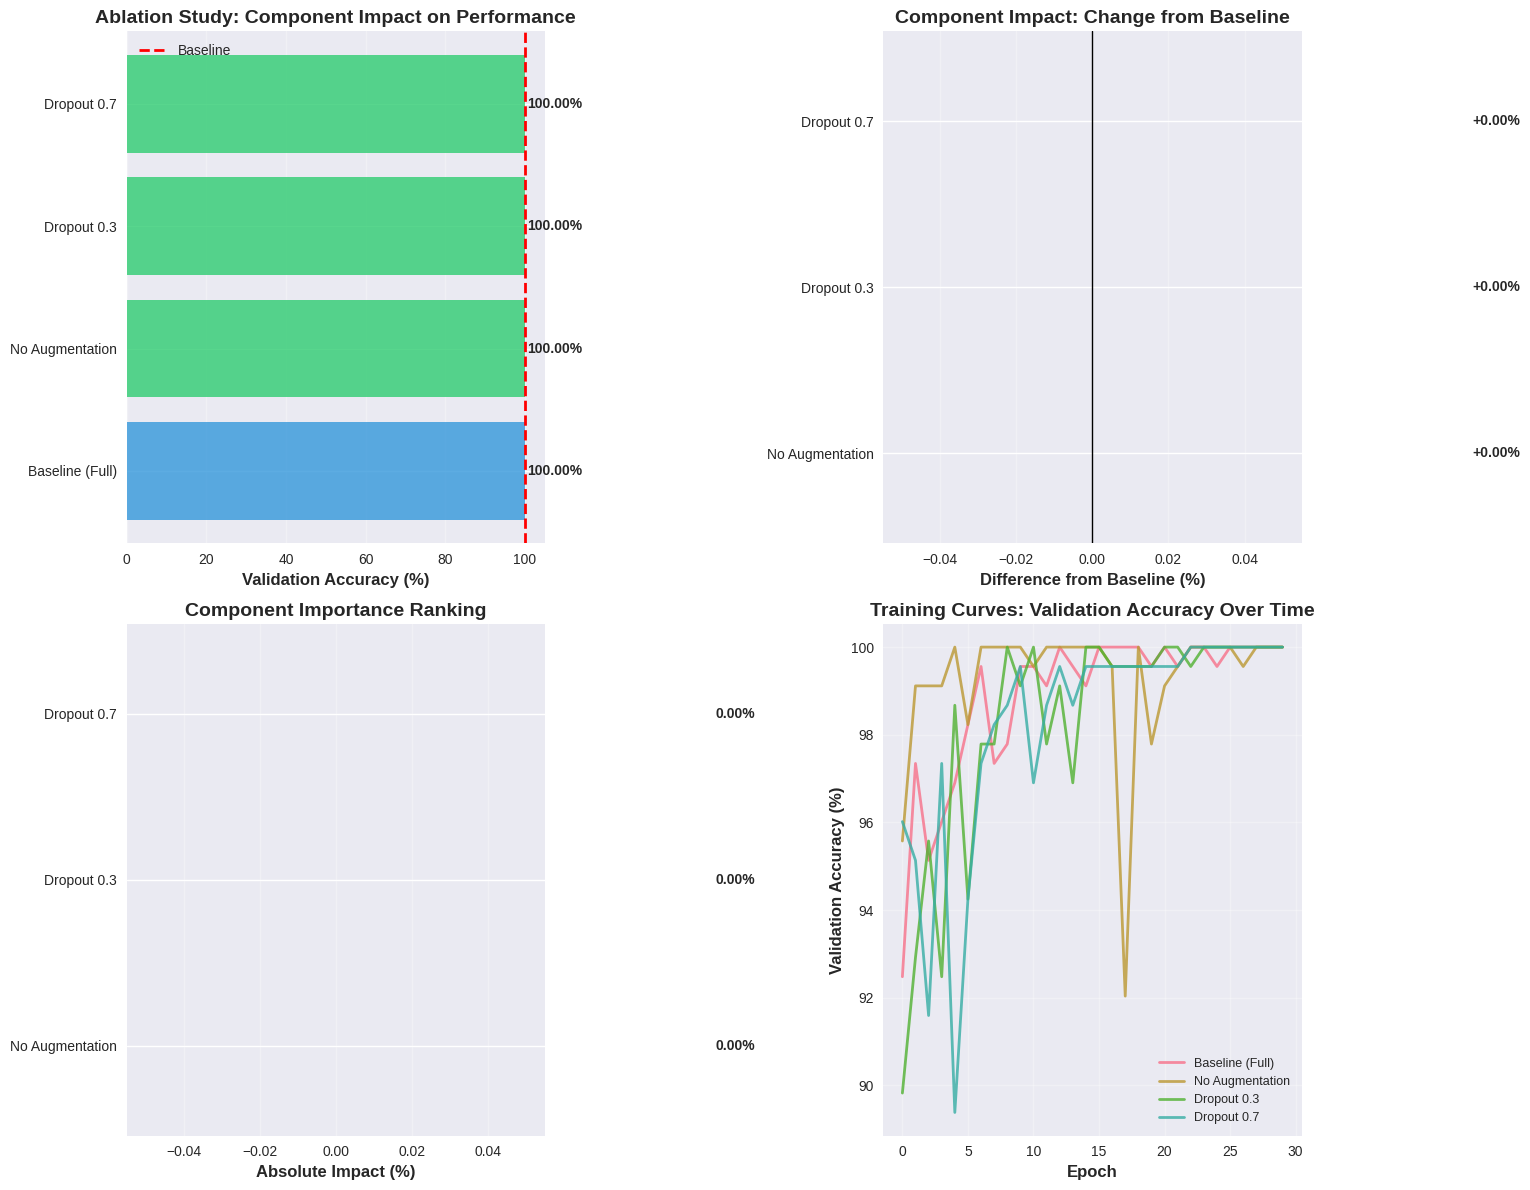


ABLATION STUDY SUMMARY

Baseline Performance: 100.00%

Component Impact Analysis:
  - No Augmentation          : 100.00% (+0.00% from baseline) [NEUTRAL]
  - Dropout 0.3              : 100.00% (+0.00% from baseline) [NEUTRAL]
  - Dropout 0.7              : 100.00% (+0.00% from baseline) [NEUTRAL]

Most Critical Component (largest negative impact): No Augmentation (+0.00%)
Most Beneficial Component (largest positive impact): No Augmentation (+0.00%)


In [24]:
# ============================================
# VISUALIZE ABLATION RESULTS
# ============================================

print("\n" + "=" * 60)
print("ABLATION STUDY RESULTS VISUALIZATION")
print("=" * 60)

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Bar chart comparing all ablation results
ax1 = axes[0, 0]
ablation_names = list(ablation_results.keys())
ablation_accs = list(ablation_results.values())
colors = ['#3498db' if 'Baseline' in name else '#e74c3c' if acc < baseline_acc else '#2ecc71'
          for name, acc in zip(ablation_names, ablation_accs)]
bars = ax1.barh(ablation_names, ablation_accs, color=colors, alpha=0.8)
ax1.axvline(x=baseline_acc, color='red', linestyle='--', linewidth=2, label='Baseline')
ax1.set_xlabel('Validation Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Ablation Study: Component Impact on Performance', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)
# Add value labels
for i, (name, acc) in enumerate(zip(ablation_names, ablation_accs)):
    ax1.text(acc + 0.5, i, f'{acc:.2f}%', va='center', fontweight='bold')

# 2. Impact analysis (difference from baseline)
ax2 = axes[0, 1]
impact_data = {name: acc - baseline_acc for name, acc in ablation_results.items() if name != 'Baseline (Full)'}
impact_names = list(impact_data.keys())
impact_values = list(impact_data.values())
colors_impact = ['#e74c3c' if v < 0 else '#2ecc71' for v in impact_values]
bars2 = ax2.barh(impact_names, impact_values, color=colors_impact, alpha=0.8)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Difference from Baseline (%)', fontsize=12, fontweight='bold')
ax2.set_title('Component Impact: Change from Baseline', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
# Add value labels
for i, (name, val) in enumerate(zip(impact_names, impact_values)):
    ax2.text(val + (0.1 if val >= 0 else -0.1), i, f'{val:+.2f}%',
             va='center', ha='left' if val >= 0 else 'right', fontweight='bold')

# 3. Component importance ranking
ax3 = axes[1, 0]
# Calculate absolute impact
abs_impact = {name: abs(val) for name, val in impact_data.items()}
sorted_impact = sorted(abs_impact.items(), key=lambda x: x[1], reverse=True)
sorted_names = [name for name, _ in sorted_impact]
sorted_values = [val for _, val in sorted_impact]
bars3 = ax3.barh(sorted_names, sorted_values, color='#9b59b6', alpha=0.8)
ax3.set_xlabel('Absolute Impact (%)', fontsize=12, fontweight='bold')
ax3.set_title('Component Importance Ranking', fontsize=14, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)
# Add value labels
for i, (name, val) in enumerate(zip(sorted_names, sorted_values)):
    ax3.text(val + 0.1, i, f'{val:.2f}%', va='center', fontweight='bold')

# 4. Training curves comparison
ax4 = axes[1, 1]
for name, history in ablation_history.items():
    if 'val_accs' in history:
        ax4.plot(history['val_accs'], label=name, linewidth=2, alpha=0.8)
ax4.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax4.set_ylabel('Validation Accuracy (%)', fontsize=12, fontweight='bold')
ax4.set_title('Training Curves: Validation Accuracy Over Time', fontsize=14, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "=" * 60)
print("ABLATION STUDY SUMMARY")
print("=" * 60)
print(f"\nBaseline Performance: {baseline_acc:.2f}%")
print(f"\nComponent Impact Analysis:")
for name, acc in ablation_results.items():
    if name != 'Baseline (Full)':
        diff = acc - baseline_acc
        impact = "POSITIVE" if diff > 0 else "NEGATIVE" if diff < 0 else "NEUTRAL"
        print(f"  - {name:25s}: {acc:.2f}% ({diff:+.2f}% from baseline) [{impact}]")

# Find most critical component
if impact_data:
    most_negative = min(impact_data.items(), key=lambda x: x[1])
    most_positive = max(impact_data.items(), key=lambda x: x[1])
    print(f"\nMost Critical Component (largest negative impact): {most_negative[0]} ({most_negative[1]:+.2f}%)")
    print(f"Most Beneficial Component (largest positive impact): {most_positive[0]} ({most_positive[1]:+.2f}%)")
print("=" * 60)
